In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from supabase import create_client
from itertools import combinations

In [2]:
env_file = 'kg.env'

In [3]:
if os.path.exists(env_file):
    load_dotenv(env_file, override=True)
    # ── Neo4j AuraDB ──
    NEO4J_URI = os.getenv("NEO4J_URI")
    NEO4J_USER = os.getenv("NEO4J_USER")
    NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
    NEO4J_DATABASE = os.getenv("NEO4J_DATABASE")
    # ── Supabase ──
    SUPABASE_URL = os.getenv("SUPABASE_URL")
    SUPABASE_KEY = os.getenv("SUPABASE_KEY")
    # ── Zilliz Cloud (Milvus) ──
    ZILLIZ_URI = os.getenv("ZILLIZ_URI")
    ZILLIZ_TOKEN = os.getenv("ZILLIZ_TOKEN")
    # ── AI / LLM (Jika ada di environment sistem) ──
    print(f"✅ Berhasil memuat konfigurasi dari {env_file}")
else:
    print(f"❌ File {env_file} tidak ditemukan.")

✅ Berhasil memuat konfigurasi dari kg.env


In [4]:
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
print("✅ Supabase connected")

✅ Supabase connected


# Konstruksi Relasi Kolaborasi Dosen

In [5]:
# Fetch lecturers
res_lec = supabase.table("lecturers").select("*").execute()
df_lecturers = pd.DataFrame(res_lec.data)

# Fetch papers
res_pap = supabase.table("papers").select("*").execute()
df_papers = pd.DataFrame(res_pap.data)

print(f"Lecturers: {len(df_lecturers)}, Papers: {len(df_papers)}")
df_papers[["paper_id", "title", "authors", "author_ids"]].head()

Lecturers: 129, Papers: 5


,paper_id,title,authors,author_ids
0,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,Yuni Yamasari,hn5jrnAAAAAJ
1,611f68730ecd39ae3d2e220a1bab5934,"Optimization and Evaluation of IndoBERT, BiLST...","Yuni Yamasari, Wiyli Yustanti","hn5jrnAAAAAJ, CxdwNaYAAAAJ"
2,9e706511b53e6a03c85102a28ec22c23,Rule-Based Adaptive Chatbot on WhatsApp for Vi...,"Yuni Yamasari, Ricky Eka Putra, I Made Suartan...","hn5jrnAAAAAJ, cPj-iOIAAAAJ, RvG7jG4AAAAJ, N6RJ..."
3,c22ca9990dfa61fb5ebe52417afbe9dc,Pengembangan Sistem Informasi Persediaan Gudan...,Yuni Yamasari,hn5jrnAAAAAJ
4,e6d753b17cea230956eb8489921fb319,Analisis Kinerja Retrieval Augmented Generatio...,Yuni Yamasari,hn5jrnAAAAAJ


In [6]:
def parse_author_pairs(row):
    authors = [a.strip() for a in str(row["authors"]).split(",")]
    ids     = [i.strip() for i in str(row["author_ids"]).split(",")]
    # zip, pad jika panjang tidak sama
    max_len = max(len(authors), len(ids))
    authors += [""] * (max_len - len(authors))
    ids     += [""] * (max_len - len(ids))
    return list(zip(authors, ids))

# Explode: 1 row per (paper, author)
records = []
for _, row in df_papers.iterrows():
    for name, aid in parse_author_pairs(row):
        records.append({
            "paper_id": row["paper_id"],
            "author_name": name,
            "scholar_id": aid,
            "year": row["year"],
            "title": row["title"]
        })

df_paper_authors = pd.DataFrame(records)
print(df_paper_authors.shape)
df_paper_authors.head(8)

(9, 5)


,paper_id,author_name,scholar_id,year,title
0,466ee15b550c3170dbed731862d0f004,Yuni Yamasari,hn5jrnAAAAAJ,2026,Klasifikasi Level Retinopati Diabetik Mengguna...
1,611f68730ecd39ae3d2e220a1bab5934,Yuni Yamasari,hn5jrnAAAAAJ,2025,"Optimization and Evaluation of IndoBERT, BiLST..."
2,611f68730ecd39ae3d2e220a1bab5934,Wiyli Yustanti,CxdwNaYAAAAJ,2025,"Optimization and Evaluation of IndoBERT, BiLST..."
3,9e706511b53e6a03c85102a28ec22c23,Yuni Yamasari,hn5jrnAAAAAJ,2026,Rule-Based Adaptive Chatbot on WhatsApp for Vi...
4,9e706511b53e6a03c85102a28ec22c23,Ricky Eka Putra,cPj-iOIAAAAJ,2026,Rule-Based Adaptive Chatbot on WhatsApp for Vi...
5,9e706511b53e6a03c85102a28ec22c23,I Made Suartana,RvG7jG4AAAAJ,2026,Rule-Based Adaptive Chatbot on WhatsApp for Vi...
6,9e706511b53e6a03c85102a28ec22c23,Anita Qoiriah,N6RJilIAAAAJ,2026,Rule-Based Adaptive Chatbot on WhatsApp for Vi...
7,c22ca9990dfa61fb5ebe52417afbe9dc,Yuni Yamasari,hn5jrnAAAAAJ,2025,Pengembangan Sistem Informasi Persediaan Gudan...


In [7]:
# Match by scholar_id dulu (paling reliable)
df_matched = df_paper_authors.merge(
    df_lecturers[["nip", "nama_norm", "scholar_id", "prodi", "nidn"]],
    on="scholar_id",
    how="left"
)

matched = df_matched[df_matched["nip"].notna()]
unmatched = df_matched[df_matched["nip"].isna()]

print(f"Matched: {len(matched)}, Unmatched: {len(unmatched)}")
# Unmatched = author eksternal (bukan dosen internal) — tetap simpan sebagai node tapi beda label

Matched: 0, Unmatched: 9


In [8]:
collab_edges = []

for paper_id, group in df_paper_authors.groupby("paper_id"):
    # Ambil semua kombinasi pasangan author dalam 1 paper
    authors_in_paper = group["scholar_id"].dropna().unique().tolist()
    for a, b in combinations(authors_in_paper, 2):
        collab_edges.append({
            "scholar_id_a": a,
            "scholar_id_b": b,
            "paper_id": paper_id
        })

df_collab = pd.DataFrame(collab_edges)
print(f"Collaboration edges: {len(df_collab)}")
df_collab.head()

Collaboration edges: 7


,scholar_id_a,scholar_id_b,paper_id
0,hn5jrnAAAAAJ,CxdwNaYAAAAJ,611f68730ecd39ae3d2e220a1bab5934
1,hn5jrnAAAAAJ,cPj-iOIAAAAJ,9e706511b53e6a03c85102a28ec22c23
2,hn5jrnAAAAAJ,RvG7jG4AAAAJ,9e706511b53e6a03c85102a28ec22c23
3,hn5jrnAAAAAJ,N6RJilIAAAAJ,9e706511b53e6a03c85102a28ec22c23
4,cPj-iOIAAAAJ,RvG7jG4AAAAJ,9e706511b53e6a03c85102a28ec22c23


In [9]:
# Node "dosen/author" pakai scholar_id + nama, tanpa perlu join ke df_lecturers dulu
df_authors_nodes = df_paper_authors[["scholar_id", "author_name"]].drop_duplicates()
df_authors_nodes.head()

,scholar_id,author_name
0,hn5jrnAAAAAJ,Yuni Yamasari
2,CxdwNaYAAAAJ,Wiyli Yustanti
4,cPj-iOIAAAAJ,Ricky Eka Putra
5,RvG7jG4AAAAJ,I Made Suartana
6,N6RJilIAAAAJ,Anita Qoiriah


In [10]:
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["font.size"] = 9

In [11]:
G_collab = nx.Graph()

# Tambah edge antar author berdasarkan scholar_id
for _, row in df_collab.iterrows():
    a = row["scholar_id_a"]
    b = row["scholar_id_b"]
    G_collab.add_edge(a, b, paper_id=row["paper_id"])

print(f"Nodes: {G_collab.number_of_nodes()}, Edges: {G_collab.number_of_edges()}")

# Tambah label nama (kalau ada) dari df_paper_authors
name_map = (
    df_paper_authors[["scholar_id", "author_name"]]
    .drop_duplicates()
    .set_index("scholar_id")["author_name"]
    .to_dict()
)
labels = {n: name_map.get(n, n) for n in G_collab.nodes()}
labels

Nodes: 5, Edges: 7


{'hn5jrnAAAAAJ': 'Yuni Yamasari',
 'CxdwNaYAAAAJ': 'Wiyli Yustanti',
 'cPj-iOIAAAAJ': 'Ricky Eka Putra',
 'RvG7jG4AAAAJ': 'I Made Suartana',
 'N6RJilIAAAAJ': 'Anita Qoiriah'}

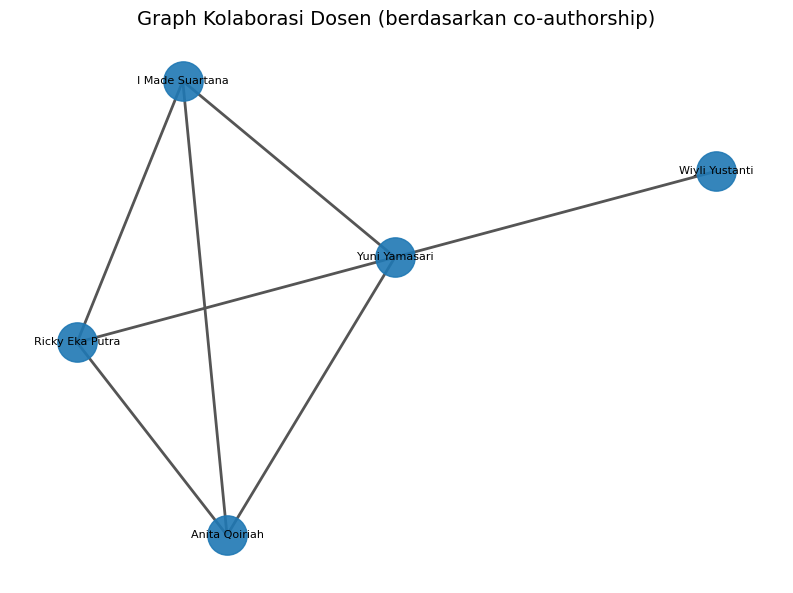

In [12]:
plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G_collab, seed=42, k=0.8)

nx.draw_networkx_nodes(
    G_collab, pos,
    node_color="#1f78b4",
    node_size=800,
    alpha=0.9
)

nx.draw_networkx_edges(
    G_collab, pos,
    edge_color="#555555",
    width=2.0
)

nx.draw_networkx_labels(
    G_collab, pos,
    labels=labels,
    font_size=8
)

plt.title("Graph Kolaborasi Dosen (berdasarkan co-authorship)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
G_full = nx.Graph()

# 1) Node Paper
for _, row in df_paper_authors.drop_duplicates(subset=["paper_id"])[["paper_id", "title"]].iterrows():
    G_full.add_node(
        f"P:{row['paper_id']}",
        label=row["title"][:40] + "...",
        type="Paper"
    )

# 2) Node Author + edge AUTHORED
for _, row in df_paper_authors.iterrows():
    a_id = row["scholar_id"]
    a_name = row["author_name"]
    author_node = f"A:{a_id}"

    if author_node not in G_full:
        G_full.add_node(
            author_node,
            label=a_name,
            type="Author"
        )

    G_full.add_edge(
        author_node,
        f"P:{row['paper_id']}",
        rel="AUTHORED"
    )

# 3) Edge COLLABORATED_WITH antar Author
for _, row in df_collab.iterrows():
    a = f"A:{row['scholar_id_a']}"
    b = f"A:{row['scholar_id_b']}"
    if a in G_full and b in G_full:
        # multiple papers akan menambah parallel info via list
        if G_full.has_edge(a, b):
            G_full[a][b].setdefault("papers", []).append(row["paper_id"])
        else:
            G_full.add_edge(
                a, b,
                rel="COLLABORATED_WITH",
                papers=[row["paper_id"]]
            )

print(f"G_full -> Nodes: {G_full.number_of_nodes()}, Edges: {G_full.number_of_edges()}")

G_full -> Nodes: 10, Edges: 16


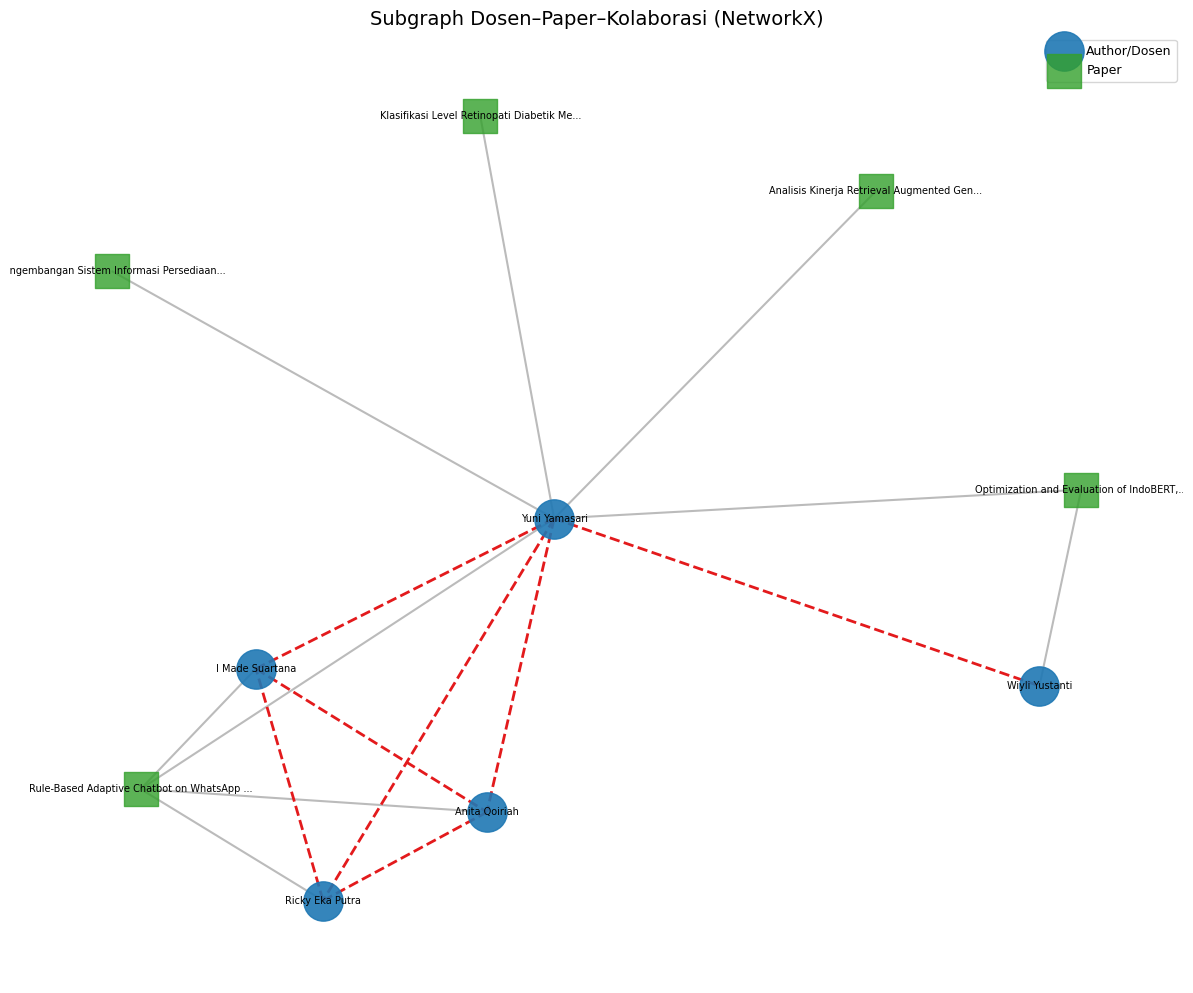

In [14]:
pos = nx.spring_layout(G_full, seed=42, k=0.9)

author_nodes = [n for n, d in G_full.nodes(data=True) if d.get("type") == "Author"]
paper_nodes  = [n for n, d in G_full.nodes(data=True) if d.get("type") == "Paper"]

labels = {n: d.get("label", n) for n, d in G_full.nodes(data=True)}

plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(
    G_full, pos,
    nodelist=author_nodes,
    node_color="#1f78b4",
    node_size=800,
    alpha=0.9,
    label="Author/Dosen"
)

nx.draw_networkx_nodes(
    G_full, pos,
    nodelist=paper_nodes,
    node_color="#33a02c",
    node_shape="s",
    node_size=600,
    alpha=0.8,
    label="Paper"
)

authored_edges = [(u, v) for u, v, d in G_full.edges(data=True) if d.get("rel") == "AUTHORED"]
collab_edges   = [(u, v) for u, v, d in G_full.edges(data=True) if d.get("rel") == "COLLABORATED_WITH"]

nx.draw_networkx_edges(
    G_full, pos,
    edgelist=authored_edges,
    edge_color="#bbbbbb",
    width=1.5,
    style="solid"
)

nx.draw_networkx_edges(
    G_full, pos,
    edgelist=collab_edges,
    edge_color="#e31a1c",
    width=2.0,
    style="dashed"
)

nx.draw_networkx_labels(
    G_full, pos,
    labels=labels,
    font_size=7
)

plt.title("Subgraph Dosen–Paper–Kolaborasi (NetworkX)")
plt.axis("off")
plt.legend(scatterpoints=1)
plt.tight_layout()
plt.show()

# Subgraph Kolaborasi Dosen via Co-authorship

In [15]:
# Ambil kolom keywords dari papers
df_keywords_raw = df_papers[["paper_id", "title", "keywords"]].copy()

print(df_keywords_raw.shape)
df_keywords_raw.head()

(5, 3)


,paper_id,title,keywords
0,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,"retinopati diabetik, vision transformer, effic..."
1,611f68730ecd39ae3d2e220a1bab5934,"Optimization and Evaluation of IndoBERT, BiLST...","indobert, text classification, complaint subca..."
2,9e706511b53e6a03c85102a28ec22c23,Rule-Based Adaptive Chatbot on WhatsApp for Vi...,"computer science, chatbot, machine learning, p..."
3,c22ca9990dfa61fb5ebe52417afbe9dc,Pengembangan Sistem Informasi Persediaan Gudan...,"sistem informasi, persediaan gudang, pieces, web"
4,e6d753b17cea230956eb8489921fb319,Analisis Kinerja Retrieval Augmented Generatio...,"retrieval augmented generation (rag), rag klas..."


In [16]:
import re
import pandas as pd

def split_keywords(text: str):
    """Split string keywords menjadi list clean."""
    if text is None:
        return []
    # ganti ; jadi , biar seragam
    text = str(text)
    text = text.replace(";", ",")
    parts = [p.strip() for p in text.split(",")]
    return [p for p in parts if p]  # drop kosong

def normalize_keyword(text: str) -> str:
    """Normalisasi sederhana untuk keyword."""
    if text is None:
        return ""
    # lower, trim, hapus punctuation di ujung, normalisasi whitespace
    t = text.lower().strip()
    t = re.sub(r"\s+", " ", t)
    t = t.strip(" .;:,")
    return t

records = []
for _, row in df_keywords_raw.iterrows():
    kws = split_keywords(row["keywords"])
    for pos, kw in enumerate(kws):
        records.append({
            "paper_id": row["paper_id"],
            "title": row["title"],
            "raw_keyword": kw,
            "keyword_norm": normalize_keyword(kw),
            "position": pos
        })

df_keyword_mentions = pd.DataFrame(records)
print(df_keyword_mentions.shape)
df_keyword_mentions.head(10)

(32, 5)


,paper_id,title,raw_keyword,keyword_norm,position
0,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,retinopati diabetik,retinopati diabetik,0
1,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,vision transformer,vision transformer,1
2,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,efficientnet,efficientnet,2
3,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,hybrid model,hybrid model,3
4,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,klasifikasi citra,klasifikasi citra,4
5,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,deep learning downloads download data,deep learning downloads download data,5
6,611f68730ecd39ae3d2e220a1bab5934,"Optimization and Evaluation of IndoBERT, BiLST...",indobert,indobert,0
7,611f68730ecd39ae3d2e220a1bab5934,"Optimization and Evaluation of IndoBERT, BiLST...",text classification,text classification,1
8,611f68730ecd39ae3d2e220a1bab5934,"Optimization and Evaluation of IndoBERT, BiLST...",complaint subcategory,complaint subcategory,2
9,9e706511b53e6a03c85102a28ec22c23,Rule-Based Adaptive Chatbot on WhatsApp for Vi...,computer science,computer science,0


In [17]:
from rdflib import Graph, Namespace
from rdflib.namespace import SKOS, RDF

IEEE_THESAURUS_TTL = "ieee-thesaurus.ttl"   # di folder yang sama dengan notebook
IEEE_TAXONOMY_TTL = "ieee-taxonomy.ttl"     # kalau mau pakai taxonomy juga

print("✅ RDFlib & paths set")

✅ RDFlib & paths set


In [18]:
g_thes = Graph()
g_thes.parse(IEEE_THESAURUS_TTL, format="turtle")
print(f"Thesaurus triples: {len(g_thes)}")

Thesaurus triples: 59674


In [19]:
records = []

for s in g_thes.subjects(RDF.type, SKOS.Concept):
    pref_labels = list(g_thes.objects(s, SKOS.prefLabel))
    alt_labels  = list(g_thes.objects(s, SKOS.altLabel))

    # Bisa ada lebih dari satu prefLabel, tapi biasanya 1
    for pl in pref_labels or [None]:
        records.append({
            "concept_uri": str(s),
            "pref_label": str(pl) if pl is not None else None,
            "alt_labels": [str(a) for a in alt_labels] if alt_labels else [],
            "source": "ieee-thesaurus"
        })

df_ieee_thes = pd.DataFrame(records).drop_duplicates(subset=["concept_uri"])
print(df_ieee_thes.shape)
df_ieee_thes.head()

(15247, 4)


,concept_uri,pref_label,alt_labels,source
0,https://ieee-thesaurus.org/schema#1f,1/f noise,[],ieee-thesaurus
1,https://ieee-thesaurus.org/schema#21cn,Next generation networking,[],ieee-thesaurus
2,https://ieee-thesaurus.org/schema#21st_century...,Next generation networking,[],ieee-thesaurus
3,https://ieee-thesaurus.org/schema#2_d_displays,Two-dimensional displays,[],ieee-thesaurus
4,https://ieee-thesaurus.org/schema#2_d_hole_gas,Two dimensional hole gas,[],ieee-thesaurus


In [20]:
# Kalau belum ada di notebook ini, copas fungsi normalize_keyword dari cell keyword.
# Di sini kita pakai fungsi yang sama:

df_ieee_thes["pref_label_norm"] = df_ieee_thes["pref_label"].apply(normalize_keyword)

def normalize_list(lst):
    return [normalize_keyword(x) for x in lst] if isinstance(lst, list) else []

df_ieee_thes["alt_labels_norm"] = df_ieee_thes["alt_labels"].apply(normalize_list)

df_ieee_thes[["concept_uri", "pref_label", "pref_label_norm", "alt_labels_norm"]].head(10)

,concept_uri,pref_label,pref_label_norm,alt_labels_norm
0,https://ieee-thesaurus.org/schema#1f,1/f noise,1/f noise,[]
1,https://ieee-thesaurus.org/schema#21cn,Next generation networking,next generation networking,[]
2,https://ieee-thesaurus.org/schema#21st_century...,Next generation networking,next generation networking,[]
3,https://ieee-thesaurus.org/schema#2_d_displays,Two-dimensional displays,two-dimensional displays,[]
4,https://ieee-thesaurus.org/schema#2_d_hole_gas,Two dimensional hole gas,two dimensional hole gas,[]
5,https://ieee-thesaurus.org/schema#2_d_photonic...,Photonic crystals,photonic crystals,[]
6,https://ieee-thesaurus.org/schema#2d_displays,Two-dimensional displays,two-dimensional displays,[]
7,https://ieee-thesaurus.org/schema#2d_hole_gas,Two dimensional hole gas,two dimensional hole gas,[]
8,https://ieee-thesaurus.org/schema#2d_photonic_...,Photonic crystals,photonic crystals,[]
9,https://ieee-thesaurus.org/schema#3_d_displays,Three-dimensional displays,three-dimensional displays,[]


In [21]:
# Index pref_label_norm -> concept_uri
pref_index = (
    df_ieee_thes[["pref_label_norm", "concept_uri"]]
    .dropna()
    .drop_duplicates()
    .set_index("pref_label_norm")["concept_uri"]
    .to_dict()
)

# Index alt_label_norm -> concept_uri
alt_records = []
for _, row in df_ieee_thes.iterrows():
    for alt in row["alt_labels_norm"]:
        alt_records.append({"alt_norm": alt, "concept_uri": row["concept_uri"]})

df_alt = pd.DataFrame(alt_records)
alt_index = (
    df_alt.drop_duplicates(subset=["alt_norm", "concept_uri"])
    .set_index("alt_norm")["concept_uri"]
    .to_dict()
)

print(f"Pref index size: {len(pref_index)}")
print(f"Alt index size: {len(alt_index)}")

Pref index size: 3366
Alt index size: 2812


In [22]:
match_records = []

for _, row in df_keyword_mentions.iterrows():
    kn = row["keyword_norm"]
    c_uri = None
    match_type = None

    # 1) exact match ke prefLabel
    if kn in pref_index:
        c_uri = pref_index[kn]
        match_type = "pref_exact"
    # 2) exact match ke altLabel
    elif kn in alt_index:
        c_uri = alt_index[kn]
        match_type = "alt_exact"

    match_records.append({
        "paper_id": row["paper_id"],
        "raw_keyword": row["raw_keyword"],
        "keyword_norm": kn,
        "concept_uri": c_uri,
        "match_type": match_type
    })

df_keyword_links = pd.DataFrame(match_records)
print(df_keyword_links.shape)
df_keyword_links.head(15)

(32, 5)


,paper_id,raw_keyword,keyword_norm,concept_uri,match_type
0,466ee15b550c3170dbed731862d0f004,retinopati diabetik,retinopati diabetik,None,None
1,466ee15b550c3170dbed731862d0f004,vision transformer,vision transformer,None,None
2,466ee15b550c3170dbed731862d0f004,efficientnet,efficientnet,None,None
3,466ee15b550c3170dbed731862d0f004,hybrid model,hybrid model,None,None
4,466ee15b550c3170dbed731862d0f004,klasifikasi citra,klasifikasi citra,None,None
5,466ee15b550c3170dbed731862d0f004,deep learning downloads download data,deep learning downloads download data,None,None
6,611f68730ecd39ae3d2e220a1bab5934,indobert,indobert,None,None
7,611f68730ecd39ae3d2e220a1bab5934,text classification,text classification,https://ieee-thesaurus.org/schema#text_categor...,alt_exact
8,611f68730ecd39ae3d2e220a1bab5934,complaint subcategory,complaint subcategory,None,None
9,9e706511b53e6a03c85102a28ec22c23,computer science,computer science,https://ieee-thesaurus.org/schema#computer_eng...,pref_exact


In [23]:
total_mentions = len(df_keyword_links)
matched_pref = (df_keyword_links["match_type"] == "pref_exact").sum()
matched_alt  = (df_keyword_links["match_type"] == "alt_exact").sum()
matched_total = matched_pref + matched_alt

print(f"Total keyword mentions: {total_mentions}")
print(f"Matched pref_exact: {matched_pref}")
print(f"Matched alt_exact: {matched_alt}")
print(f"Matched total: {matched_total} ({matched_total / max(total_mentions,1):.1%})")

df_keyword_links.sample(10, random_state=42)

Total keyword mentions: 32
Matched pref_exact: 3
Matched alt_exact: 1
Matched total: 4 (12.5%)


,paper_id,raw_keyword,keyword_norm,concept_uri,match_type
29,e6d753b17cea230956eb8489921fb319,bm25,bm25,None,None
15,9e706511b53e6a03c85102a28ec22c23,discriminative model,discriminative model,None,None
24,c22ca9990dfa61fb5ebe52417afbe9dc,persediaan gudang,persediaan gudang,None,None
17,9e706511b53e6a03c85102a28ec22c23,conversation,conversation,None,None
8,611f68730ecd39ae3d2e220a1bab5934,complaint subcategory,complaint subcategory,None,None
9,9e706511b53e6a03c85102a28ec22c23,computer science,computer science,https://ieee-thesaurus.org/schema#computer_eng...,pref_exact
30,e6d753b17cea230956eb8489921fb319,multimodal,multimodal,None,None
25,c22ca9990dfa61fb5ebe52417afbe9dc,pieces,pieces,None,None
12,9e706511b53e6a03c85102a28ec22c23,probabilistic logic,probabilistic logic,None,None
0,466ee15b550c3170dbed731862d0f004,retinopati diabetik,retinopati diabetik,None,None


In [24]:
# Hanya konsep yang benar-benar terpakai oleh keyword paper
df_concepts_used = (
    df_keyword_links[df_keyword_links["concept_uri"].notna()][["concept_uri"]]
    .drop_duplicates()
    .merge(df_ieee_thes, on="concept_uri", how="left")
)

print(df_concepts_used.shape)
df_concepts_used.head(10)

(4, 6)


,concept_uri,pref_label,alt_labels,source,pref_label_norm,alt_labels_norm
0,https://ieee-thesaurus.org/schema#text_categor...,Text categorization,[Text classification],ieee-thesaurus,text categorization,[text classification]
1,https://ieee-thesaurus.org/schema#computer_eng...,Computer science,[],ieee-thesaurus,computer science,[]
2,https://ieee-thesaurus.org/schema#machine_lear...,Machine learning,[],ieee-thesaurus,machine learning,[]
3,https://ieee-thesaurus.org/schema#artificial_i...,Artificial intelligence,[AI],ieee-thesaurus,artificial intelligence,[ai]


In [25]:
# Node Concept yang benar-benar terpakai oleh keyword paper
df_concepts_used = (
    df_keyword_links[df_keyword_links["concept_uri"].notna()][["concept_uri"]]
    .drop_duplicates()
    .merge(df_ieee_thes, on="concept_uri", how="left")
)

print(df_concepts_used.shape)
df_concepts_used.head(10)

(4, 6)


,concept_uri,pref_label,alt_labels,source,pref_label_norm,alt_labels_norm
0,https://ieee-thesaurus.org/schema#text_categor...,Text categorization,[Text classification],ieee-thesaurus,text categorization,[text classification]
1,https://ieee-thesaurus.org/schema#computer_eng...,Computer science,[],ieee-thesaurus,computer science,[]
2,https://ieee-thesaurus.org/schema#machine_lear...,Machine learning,[],ieee-thesaurus,machine learning,[]
3,https://ieee-thesaurus.org/schema#artificial_i...,Artificial intelligence,[AI],ieee-thesaurus,artificial intelligence,[ai]


In [26]:
# Edge Paper -> KeywordMention (opsional, kalau mau node mention terpisah)
df_keyword_mentions_mapped = df_keyword_mentions.merge(
    df_keyword_links[["paper_id", "raw_keyword", "concept_uri", "match_type"]],
    on=["paper_id", "raw_keyword"],
    how="left",
)

df_keyword_mentions_mapped.head(10)

,paper_id,title,raw_keyword,keyword_norm,position,concept_uri,match_type
0,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,retinopati diabetik,retinopati diabetik,0,None,None
1,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,vision transformer,vision transformer,1,None,None
2,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,efficientnet,efficientnet,2,None,None
3,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,hybrid model,hybrid model,3,None,None
4,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,klasifikasi citra,klasifikasi citra,4,None,None
5,466ee15b550c3170dbed731862d0f004,Klasifikasi Level Retinopati Diabetik Mengguna...,deep learning downloads download data,deep learning downloads download data,5,None,None
6,611f68730ecd39ae3d2e220a1bab5934,"Optimization and Evaluation of IndoBERT, BiLST...",indobert,indobert,0,None,None
7,611f68730ecd39ae3d2e220a1bab5934,"Optimization and Evaluation of IndoBERT, BiLST...",text classification,text classification,1,https://ieee-thesaurus.org/schema#text_categor...,alt_exact
8,611f68730ecd39ae3d2e220a1bab5934,"Optimization and Evaluation of IndoBERT, BiLST...",complaint subcategory,complaint subcategory,2,None,None
9,9e706511b53e6a03c85102a28ec22c23,Rule-Based Adaptive Chatbot on WhatsApp for Vi...,computer science,computer science,0,https://ieee-thesaurus.org/schema#computer_eng...,pref_exact


Nodes: 41, Edges: 36


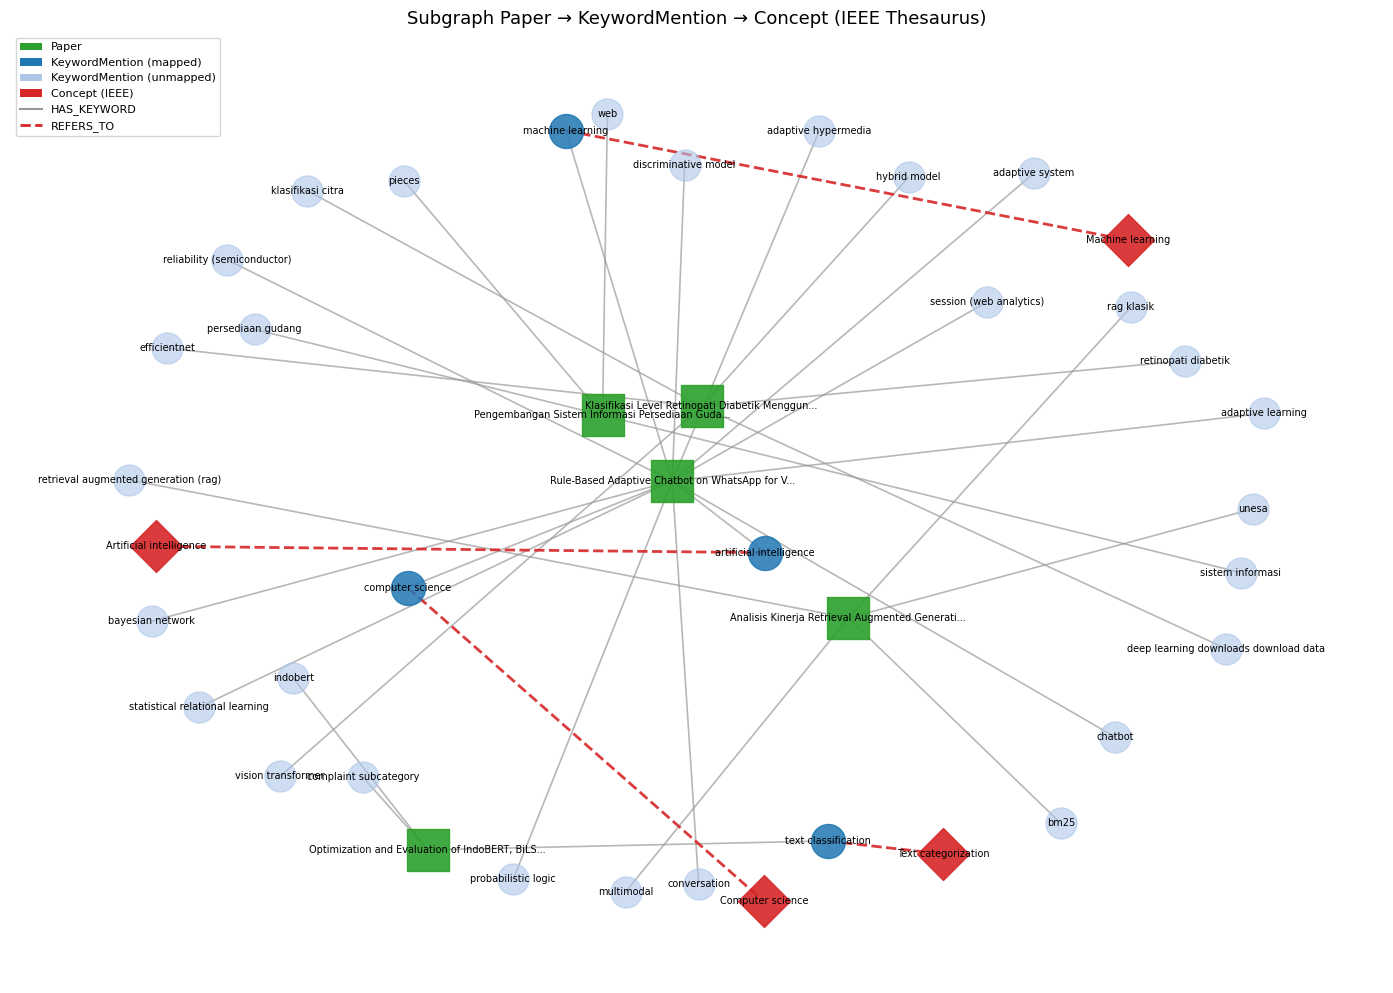

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

G_kw = nx.Graph()

# Ambil semua paper yang ada di df_keyword_mentions_mapped
sample_papers = df_keyword_mentions_mapped["paper_id"].unique()

for _, row in df_keyword_mentions_mapped.iterrows():
    p_id  = f"P:{row['paper_id']}"
    kw_id = f"KW:{row['paper_id']}:{row['position']}"
    c_uri = row.get("concept_uri")
    c_id  = f"C:{c_uri}" if pd.notna(c_uri) else None

    # --- node Paper ---
    if p_id not in G_kw:
        # ambil judul dari df_papers
        title_val = df_papers[df_papers["paper_id"] == row["paper_id"]]["title"].values
        title_str = title_val[0][:45] + "..." if len(title_val) > 0 else str(row["paper_id"])
        G_kw.add_node(p_id, label=title_str, type="Paper")

    # --- node KeywordMention ---
    G_kw.add_node(kw_id, label=row["raw_keyword"], type="KeywordMention")
    G_kw.add_edge(p_id, kw_id, rel="HAS_KEYWORD")

    # --- node Concept (hanya kalau ada mapping) ---
    if c_id:
        if c_id not in G_kw:
            concept_row = df_concepts_used[df_concepts_used["concept_uri"] == c_uri]
            pref = concept_row["pref_label"].values[0] if len(concept_row) > 0 else c_uri
            G_kw.add_node(c_id, label=str(pref)[:40], type="Concept")
        G_kw.add_edge(
            kw_id, c_id,
            rel="REFERS_TO",
            match_type=row.get("match_type", "")
        )

print(f"Nodes: {G_kw.number_of_nodes()}, Edges: {G_kw.number_of_edges()}")

# ── pisah node per type ──────────────────────────────────────────────────────
paper_nodes   = [n for n, d in G_kw.nodes(data=True) if d.get("type") == "Paper"]
kw_nodes      = [n for n, d in G_kw.nodes(data=True) if d.get("type") == "KeywordMention"]
concept_nodes = [n for n, d in G_kw.nodes(data=True) if d.get("type") == "Concept"]

# ── unmapped keyword (tidak punya edge ke Concept) ───────────────────────────
unmapped_kw = [
    n for n in kw_nodes
    if not any(
        G_kw.nodes[nb].get("type") == "Concept"
        for nb in G_kw.neighbors(n)
    )
]
mapped_kw = [n for n in kw_nodes if n not in unmapped_kw]

# ── layout ───────────────────────────────────────────────────────────────────
pos = nx.spring_layout(G_kw, seed=42, k=1.2)

labels = {n: d.get("label", n) for n, d in G_kw.nodes(data=True)}

# ── gambar ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

# Paper → hijau kotak
nx.draw_networkx_nodes(G_kw, pos, nodelist=paper_nodes,
                       node_color="#2ca02c", node_shape="s",
                       node_size=900, alpha=0.9, ax=ax)

# KeywordMention mapped → biru
nx.draw_networkx_nodes(G_kw, pos, nodelist=mapped_kw,
                       node_color="#1f77b4", node_size=600,
                       alpha=0.85, ax=ax)

# KeywordMention unmapped → abu-abu
nx.draw_networkx_nodes(G_kw, pos, nodelist=unmapped_kw,
                       node_color="#aec7e8", node_size=500,
                       alpha=0.6, ax=ax)

# Concept → merah diamond
nx.draw_networkx_nodes(G_kw, pos, nodelist=concept_nodes,
                       node_color="#d62728", node_shape="D",
                       node_size=700, alpha=0.9, ax=ax)

# Edges HAS_KEYWORD → abu solid
has_kw_edges = [(u, v) for u, v, d in G_kw.edges(data=True) if d.get("rel") == "HAS_KEYWORD"]
refers_edges = [(u, v) for u, v, d in G_kw.edges(data=True) if d.get("rel") == "REFERS_TO"]

nx.draw_networkx_edges(G_kw, pos, edgelist=has_kw_edges,
                       edge_color="#999999", width=1.2,
                       style="solid", alpha=0.7, ax=ax)

nx.draw_networkx_edges(G_kw, pos, edgelist=refers_edges,
                       edge_color="#d62728", width=2.0,
                       style="dashed", alpha=0.9, ax=ax)

nx.draw_networkx_labels(G_kw, pos, labels=labels,
                        font_size=7, ax=ax)

# Legend manual
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ca02c", label="Paper"),
    Patch(facecolor="#1f77b4", label="KeywordMention (mapped)"),
    Patch(facecolor="#aec7e8", label="KeywordMention (unmapped)"),
    Patch(facecolor="#d62728", label="Concept (IEEE)"),
    Line2D([0],[0], color="#999999", lw=1.5, linestyle="-",  label="HAS_KEYWORD"),
    Line2D([0],[0], color="#d62728", lw=2.0, linestyle="--", label="REFERS_TO"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=8)

ax.set_title("Subgraph Paper → KeywordMention → Concept (IEEE Thesaurus)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

# konstruksi keyword

In [28]:
# ─── CELL A ── FIX matched: gunakan nama_norm bukan scholar_id ───────────────
# scholar_id di df_lecturers kosong semua → fallback ke normalisasi nama

import unicodedata, re

def normalize_name(name: str) -> str:
    """Lowercase, remove diacritics, strip whitespace berlebih."""
    if not isinstance(name, str):
        return ""
    name = unicodedata.normalize("NFKD", name)
    name = "".join(c for c in name if not unicodedata.combining(c))
    name = re.sub(r"\s+", " ", name).strip().lower()
    return name

# Buat lookup: nama_norm_clean → row lecturers
df_lecturers["_nama_key"] = df_lecturers["nama_norm"].apply(normalize_name)
lec_lookup = df_lecturers.set_index("_nama_key").to_dict("index")

# Match df_paper_authors.author_name → lecturers
def match_lecturer(author_name):
    key = normalize_name(author_name)
    # exact match dulu
    if key in lec_lookup:
        return lec_lookup[key]
    # fallback: cek apakah key ada sebagai substring di nama dosen (atau sebaliknya)
    for lec_key, lec_row in lec_lookup.items():
        if key in lec_key or lec_key in key:
            return lec_row
    return None

matched_rows = []
for _, row in df_paper_authors.iterrows():
    lec = match_lecturer(row["author_name"])
    if lec:
        matched_rows.append({
            "paper_id":   row["paper_id"],
            "author_name": row["author_name"],
            "scholar_id": row["scholar_id"],
            "year":       row["year"],
            "title":      row["title"],
            "nip":        lec.get("nip"),
            "nama_norm":  lec.get("nama_norm"),
            "prodi":      lec.get("prodi"),
            "nidn":       lec.get("nidn"),
            "scopus_id":  lec.get("scopus_id"),
            "sinta_id":   lec.get("sinta_id"),
        })

matched    = pd.DataFrame(matched_rows)
unmatched  = df_paper_authors[
    ~df_paper_authors["author_name"].apply(
        lambda x: match_lecturer(x) is not None
    )
]

print(f"✅ Matched (dosen internal): {len(matched)}")
print(f"❌ Unmatched (eksternal):    {len(unmatched)}")
print(matched[["author_name", "nama_norm", "nip", "prodi"]].drop_duplicates())

✅ Matched (dosen internal): 9
❌ Unmatched (eksternal):    0
       author_name        nama_norm                 nip                  prodi
0    Yuni Yamasari    Yuni Yamasari  197506022003122001         S2 Informatika
2   Wiyli Yustanti   Wiyli Yustanti  197702032005012001         S2 Informatika
4  Ricky Eka Putra  Ricky Eka Putra  198701162018031001         S2 Informatika
5  I Made Suartana  I Made Suartana  198411242015041003  S1 Teknik Informatika
6    Anita Qoiriah    Anita Qoiriah  196901251995122001  S1 Teknik Informatika


In [29]:
# ─── CELL B ── Rebuild kolaborasi dari matched dosen internal ─────────────────
from itertools import combinations

# Kolaborasi antar sesama dosen internal (nip berbeda, paper sama)
collab_edges = []

for paper_id, group in matched.groupby("paper_id"):
    dosen_in_paper = group[["nip", "nama_norm"]].drop_duplicates().to_dict("records")
    for a, b in combinations(dosen_in_paper, 2):
        if a["nip"] != b["nip"]:
            collab_edges.append({
                "nip_a":      a["nip"],
                "nama_a":     a["nama_norm"],
                "nip_b":      b["nip"],
                "nama_b":     b["nama_norm"],
                "paper_id":   paper_id,
            })

collab_internal = pd.DataFrame(collab_edges)
print(f"✅ Collaboration edges (internal dosen): {len(collab_internal)}")
if len(collab_internal) > 0:
    print(collab_internal[["nama_a", "nama_b", "paper_id"]])

✅ Collaboration edges (internal dosen): 7
            nama_a           nama_b                          paper_id
0    Yuni Yamasari   Wiyli Yustanti  611f68730ecd39ae3d2e220a1bab5934
1    Yuni Yamasari  Ricky Eka Putra  9e706511b53e6a03c85102a28ec22c23
2    Yuni Yamasari  I Made Suartana  9e706511b53e6a03c85102a28ec22c23
3    Yuni Yamasari    Anita Qoiriah  9e706511b53e6a03c85102a28ec22c23
4  Ricky Eka Putra  I Made Suartana  9e706511b53e6a03c85102a28ec22c23
5  Ricky Eka Putra    Anita Qoiriah  9e706511b53e6a03c85102a28ec22c23
6  I Made Suartana    Anita Qoiriah  9e706511b53e6a03c85102a28ec22c23


G_collab → Nodes: 10, Edges: 16


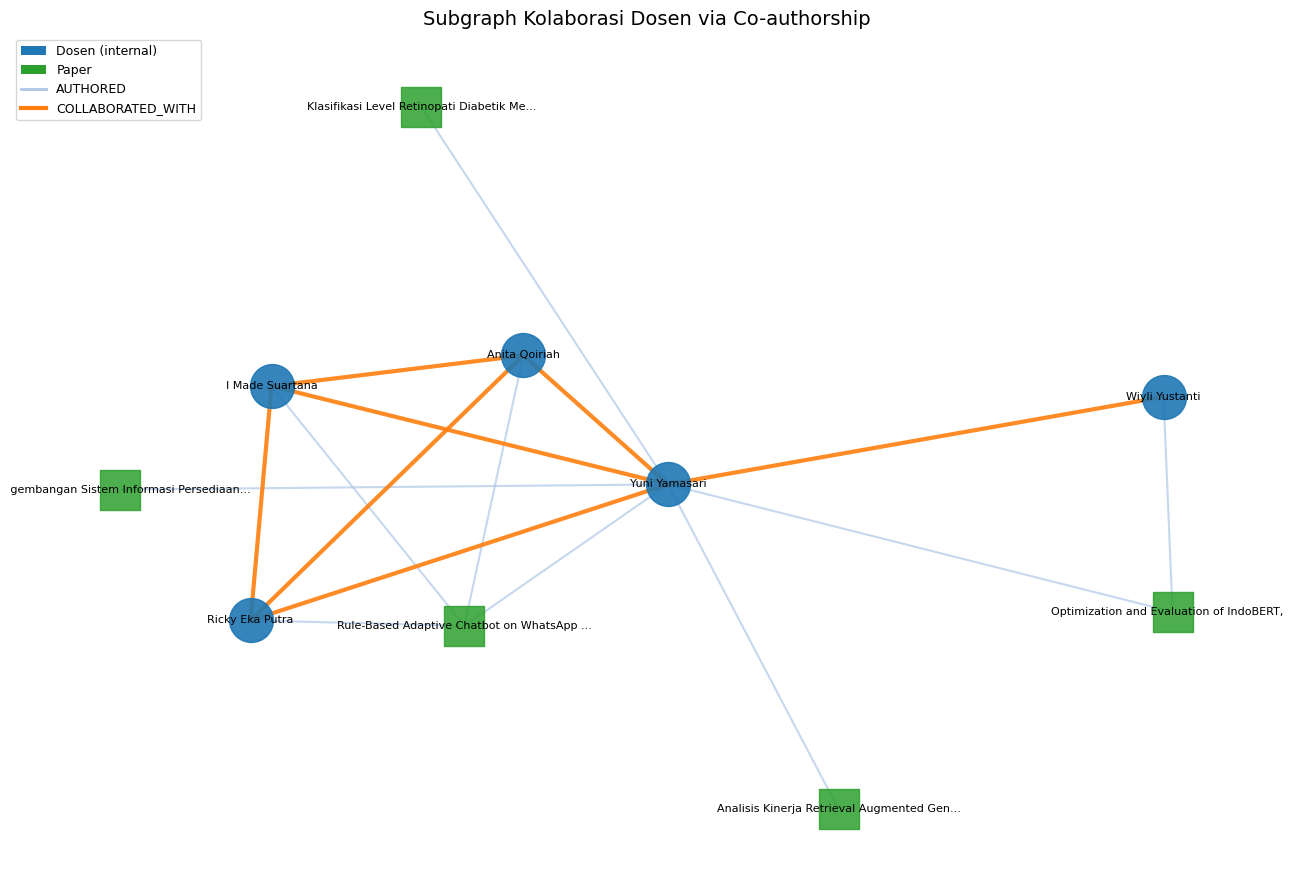

In [30]:
# ─── CELL C ── G_collab: Subgraph Kolaborasi Dosen via Co-authorship ──────────
import networkx as nx
import matplotlib.pyplot as plt

G_collab = nx.Graph()

# Node Dosen (dari matched)
for _, row in matched[["nip", "nama_norm", "prodi"]].drop_duplicates("nip").iterrows():
    G_collab.add_node(
        f"D:{row['nip']}",
        label=row["nama_norm"],
        prodi=row["prodi"],
        type="Dosen"
    )

# Node Paper (dari matched)
for _, row in matched[["paper_id", "title"]].drop_duplicates("paper_id").iterrows():
    G_collab.add_node(
        f"P:{row['paper_id']}",
        label=row["title"][:40] + "...",
        type="Paper"
    )

# Edge AUTHORED: Dosen → Paper
for _, row in matched.iterrows():
    G_collab.add_edge(
        f"D:{row['nip']}",
        f"P:{row['paper_id']}",
        rel="AUTHORED"
    )

# Edge COLLABORATED_WITH: Dosen ↔ Dosen
for _, row in collab_internal.iterrows():
    a = f"D:{row['nip_a']}"
    b = f"D:{row['nip_b']}"
    if not G_collab.has_edge(a, b):
        G_collab.add_edge(a, b, rel="COLLABORATED_WITH", papers=[row["paper_id"]])
    else:
        G_collab[a][b].setdefault("papers", []).append(row["paper_id"])

print(f"G_collab → Nodes: {G_collab.number_of_nodes()}, Edges: {G_collab.number_of_edges()}")

# ── Visualisasi ──────────────────────────────────────────────────────────────
dosen_nodes = [n for n, d in G_collab.nodes(data=True) if d.get("type") == "Dosen"]
paper_nodes = [n for n, d in G_collab.nodes(data=True) if d.get("type") == "Paper"]
authored_edges    = [(u,v) for u,v,d in G_collab.edges(data=True) if d.get("rel") == "AUTHORED"]
collab_edges_draw = [(u,v) for u,v,d in G_collab.edges(data=True) if d.get("rel") == "COLLABORATED_WITH"]

pos = nx.spring_layout(G_collab, seed=42, k=1.5)
labels = {n: d.get("label", n) for n, d in G_collab.nodes(data=True)}

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_nodes(G_collab, pos, nodelist=dosen_nodes,
                       node_color="#1f77b4", node_size=1000, alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G_collab, pos, nodelist=paper_nodes,
                       node_color="#2ca02c", node_shape="s",
                       node_size=800, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_collab, pos, edgelist=authored_edges,
                       edge_color="#aec7e8", width=1.5, style="solid", alpha=0.7, ax=ax)
nx.draw_networkx_edges(G_collab, pos, edgelist=collab_edges_draw,
                       edge_color="#ff7f0e", width=3.0, style="solid", alpha=0.9, ax=ax)
nx.draw_networkx_labels(G_collab, pos, labels=labels, font_size=8, ax=ax)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#1f77b4", label="Dosen (internal)"),
    Patch(facecolor="#2ca02c", label="Paper"),
    Line2D([0],[0], color="#aec7e8", lw=2, label="AUTHORED"),
    Line2D([0],[0], color="#ff7f0e", lw=3, label="COLLABORATED_WITH"),
], loc="upper left", fontsize=9)

ax.set_title("Subgraph Kolaborasi Dosen via Co-authorship", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [31]:
# ─── CELL D-FINAL ── Taxonomy hierarki dari ieee-thesaurus.ttl ────────────────
from rdflib import Graph
from rdflib.namespace import SKOS, RDFS
import pandas as pd, os

THES_FILE = "ieee-thesaurus.ttl"
if not os.path.exists(THES_FILE):
    THES_FILE = os.path.join("IEEE", "ieee-thesaurus.ttl")

g_thes = Graph()
g_thes.parse(THES_FILE, format="turtle")
print(f"Triples di ieee-thesaurus.ttl : {len(g_thes)}")

broader_count  = len(list(g_thes.triples((None, SKOS.broader, None))))
narrower_count = len(list(g_thes.triples((None, SKOS.narrower, None))))
print(f"skos:broader  : {broader_count}")
print(f"skos:narrower : {narrower_count}")

# ── Label map (prefLabel prioritas, fallback rdfs:label) ──────────────────────
label_map = {}
for s, _, o in g_thes.triples((None, SKOS.prefLabel, None)):
    label_map[str(s)] = str(o).strip()
for s, _, o in g_thes.triples((None, RDFS.label, None)):
    if str(s) not in label_map:
        label_map[str(s)] = str(o).strip()
print(f"Concepts dengan label: {len(label_map)}")

# ── Build edges dari broader + narrower ───────────────────────────────────────
tax_edges = []

for s, _, o in g_thes.triples((None, SKOS.broader, None)):
    cl = label_map.get(str(s), "")
    pl = label_map.get(str(o), "")
    if cl and pl and cl != pl:
        tax_edges.append({"child_label": cl, "parent_label": pl,
                          "rel": "BROADER_THAN", "source_uri": str(s)})

for s, _, o in g_thes.triples((None, SKOS.narrower, None)):
    cl = label_map.get(str(o), "")
    pl = label_map.get(str(s), "")
    if cl and pl and cl != pl:
        tax_edges.append({"child_label": cl, "parent_label": pl,
                          "rel": "BROADER_THAN", "source_uri": str(o)})

df_taxonomy_edges_full = pd.DataFrame(tax_edges).drop_duplicates(
    subset=["child_label", "parent_label"]
)
print(f"\ndf_taxonomy_edges_full: {df_taxonomy_edges_full.shape}")
print(df_taxonomy_edges_full.head(5))

# ── Filter L1+L2 berdasarkan concept yang terpakai ───────────────────────────
used_labels = set(
    df_concepts_used["pref_label_norm"].dropna().str.lower().str.strip()
)
print(f"\nConcept terpakai: {used_labels}")

df_tax = df_taxonomy_edges_full.copy()
df_tax["child_norm"]  = df_tax["child_label"].str.lower().str.strip()
df_tax["parent_norm"] = df_tax["parent_label"].str.lower().str.strip()

# L1 – langsung involve concept terpakai
direct_edges = df_tax[
    df_tax["child_norm"].isin(used_labels) |
    df_tax["parent_norm"].isin(used_labels)
]

# L2 – second hop
l1_all     = set(direct_edges["child_norm"]) | set(direct_edges["parent_norm"])
second_hop = df_tax[
    df_tax["child_norm"].isin(l1_all) |
    df_tax["parent_norm"].isin(l1_all)
]

df_taxonomy_filtered = pd.concat([direct_edges, second_hop]).drop_duplicates()
print(f"\n✅ Taxonomy edges filtered (L1+L2): {len(df_taxonomy_filtered)}")
if len(df_taxonomy_filtered) > 0:
    print(df_taxonomy_filtered[["child_label","parent_label","rel"]].to_string(index=False))
else:
    print("⚠️  Masih 0 — cek debug di bawah")
    all_tax = set(df_tax["child_norm"]) | set(df_tax["parent_norm"])
    for c in used_labels:
        hits = [l for l in all_tax if c in l or l in c]
        print(f"  '{c}': {hits[:5]}")

Triples di ieee-thesaurus.ttl : 59674
skos:broader  : 7267
skos:narrower : 2021
Concepts dengan label: 15247

df_taxonomy_edges_full: (8980, 4)
                    child_label parent_label           rel  \
0      Two-dimensional displays     Displays  BROADER_THAN   
1         Head-mounted displays     Displays  BROADER_THAN   
2  interaction Head-up displays     Displays  BROADER_THAN   
3   measurement Display systems     Displays  BROADER_THAN   
4                 Microdisplays     Displays  BROADER_THAN   

                                          source_uri  
0      https://ieee-thesaurus.org/schema#2d_displays  
1  https://ieee-thesaurus.org/schema#helmet_mount...  
2  https://ieee-thesaurus.org/schema#interaction_...  
3  https://ieee-thesaurus.org/schema#measurement_...  
4    https://ieee-thesaurus.org/schema#microdisplays  

Concept terpakai: {'text categorization', 'machine learning', 'artificial intelligence', 'computer science'}

✅ Taxonomy edges filtered (L1+L2): 146
   

In [32]:
# ─── CELL E-REBUILD ── Full Unified KG ───────────────────────────────────────
import networkx as nx
import pandas as pd
from collections import Counter

G = nx.Graph()

# ── 1. Dosen (semua, bukan hanya yang matched) ───────────────────────────────
for _, row in df_lecturers.iterrows():
    G.add_node(
        f"D:{row['nip']}",
        label=str(row["nama_norm"]),
        prodi=str(row.get("prodi", "")),
        scopus_id=str(row.get("scopus_id", "")),
        type="Dosen"
    )

# ── 2. Paper ─────────────────────────────────────────────────────────────────
for _, row in df_paper_authors.drop_duplicates("paper_id").iterrows():
    G.add_node(
        f"P:{row['paper_id']}",
        label=str(row["title"])[:45] + "...",
        year=str(row.get("year", "")),
        type="Paper"
    )

# ── 3. AUTHORED (dosen internal saja) ────────────────────────────────────────
for _, row in matched.iterrows():
    d, p = f"D:{row['nip']}", f"P:{row['paper_id']}"
    if d in G and p in G:
        G.add_edge(d, p, rel="AUTHORED")

# ── 4. COLLABORATED_WITH ─────────────────────────────────────────────────────
for _, row in collab_internal.iterrows():
    a, b = f"D:{row['nip_a']}", f"D:{row['nip_b']}"
    if a in G and b in G:
        if not G.has_edge(a, b):
            G.add_edge(a, b, rel="COLLABORATED_WITH", papers=[row["paper_id"]])
        else:
            G[a][b].setdefault("papers", []).append(row["paper_id"])

# ── 5. KeywordMention + Concept ──────────────────────────────────────────────
for _, row in df_keyword_mentions_mapped.iterrows():
    p_id  = f"P:{row['paper_id']}"
    kw_id = f"KW:{row['paper_id']}:{row['position']}"
    c_uri = row.get("concept_uri")

    G.add_node(kw_id, label=str(row["raw_keyword"])[:35], type="KeywordMention")
    if p_id in G:
        G.add_edge(p_id, kw_id, rel="HAS_KEYWORD")

    if pd.notna(c_uri) and c_uri:
        c_id = f"C:{c_uri}"
        if c_id not in G:
            cr   = df_concepts_used[df_concepts_used["concept_uri"] == c_uri]
            pref = cr["pref_label"].values[0] if len(cr) > 0 else str(c_uri)
            G.add_node(c_id, label=str(pref)[:40], type="Concept")
        G.add_edge(kw_id, c_id, rel="REFERS_TO",
                   match_type=str(row.get("match_type", "")))

# ── 6. Taxonomy nodes + BROADER_THAN ─────────────────────────────────────────
if len(df_taxonomy_filtered) > 0:
    for _, row in df_taxonomy_filtered.iterrows():
        cid = f"T:{row['child_label']}"
        pid = f"T:{row['parent_label']}"
        if cid not in G:
            G.add_node(cid, label=str(row["child_label"])[:35],  type="Taxonomy")
        if pid not in G:
            G.add_node(pid, label=str(row["parent_label"])[:35], type="Taxonomy")
        if not G.has_edge(cid, pid):
            G.add_edge(cid, pid, rel="BROADER_THAN")

# ── 7. Bridge: Concept → Taxonomy (SAME_AS berdasarkan label match) ───────────
tax_label_map = {
    d["label"].lower().strip(): n
    for n, d in G.nodes(data=True)
    if d.get("type") == "Taxonomy"
}
bridge_count = 0
for c_node, c_data in G.nodes(data=True):
    if c_data.get("type") != "Concept":
        continue
    c_lbl = c_data.get("label", "").lower().strip()
    if c_lbl in tax_label_map:
        t_node = tax_label_map[c_lbl]
        if not G.has_edge(c_node, t_node):
            G.add_edge(c_node, t_node, rel="SAME_AS")
            bridge_count += 1

# ── Summary ───────────────────────────────────────────────────────────────────
print("✅ Full KG Summary:")
print(f"   Total Nodes : {G.number_of_nodes()}")
print(f"   Total Edges : {G.number_of_edges()}")
print(f"   Bridge Concept↔Taxonomy: {bridge_count}")
print()
type_count = Counter(d.get("type","?") for _, d in G.nodes(data=True))
rel_count  = Counter(d.get("rel","?")  for _, _, d in G.edges(data=True))
for t, c in sorted(type_count.items(), key=lambda x: -x[1]):
    print(f"   {t:20s}: {c:4d} nodes")
print()
for r, c in sorted(rel_count.items(), key=lambda x: -x[1]):
    print(f"   {r:25s}: {c:4d} edges")

✅ Full KG Summary:
   Total Nodes : 318
   Total Edges : 202
   Bridge Concept↔Taxonomy: 4

   Taxonomy            :  148 nodes
   Dosen               :  129 nodes
   KeywordMention      :   32 nodes
   Paper               :    5 nodes
   Concept             :    4 nodes

   BROADER_THAN             :  146 edges
   HAS_KEYWORD              :   32 edges
   AUTHORED                 :    9 edges
   COLLABORATED_WITH        :    7 edges
   REFERS_TO                :    4 edges
   SAME_AS                  :    4 edges


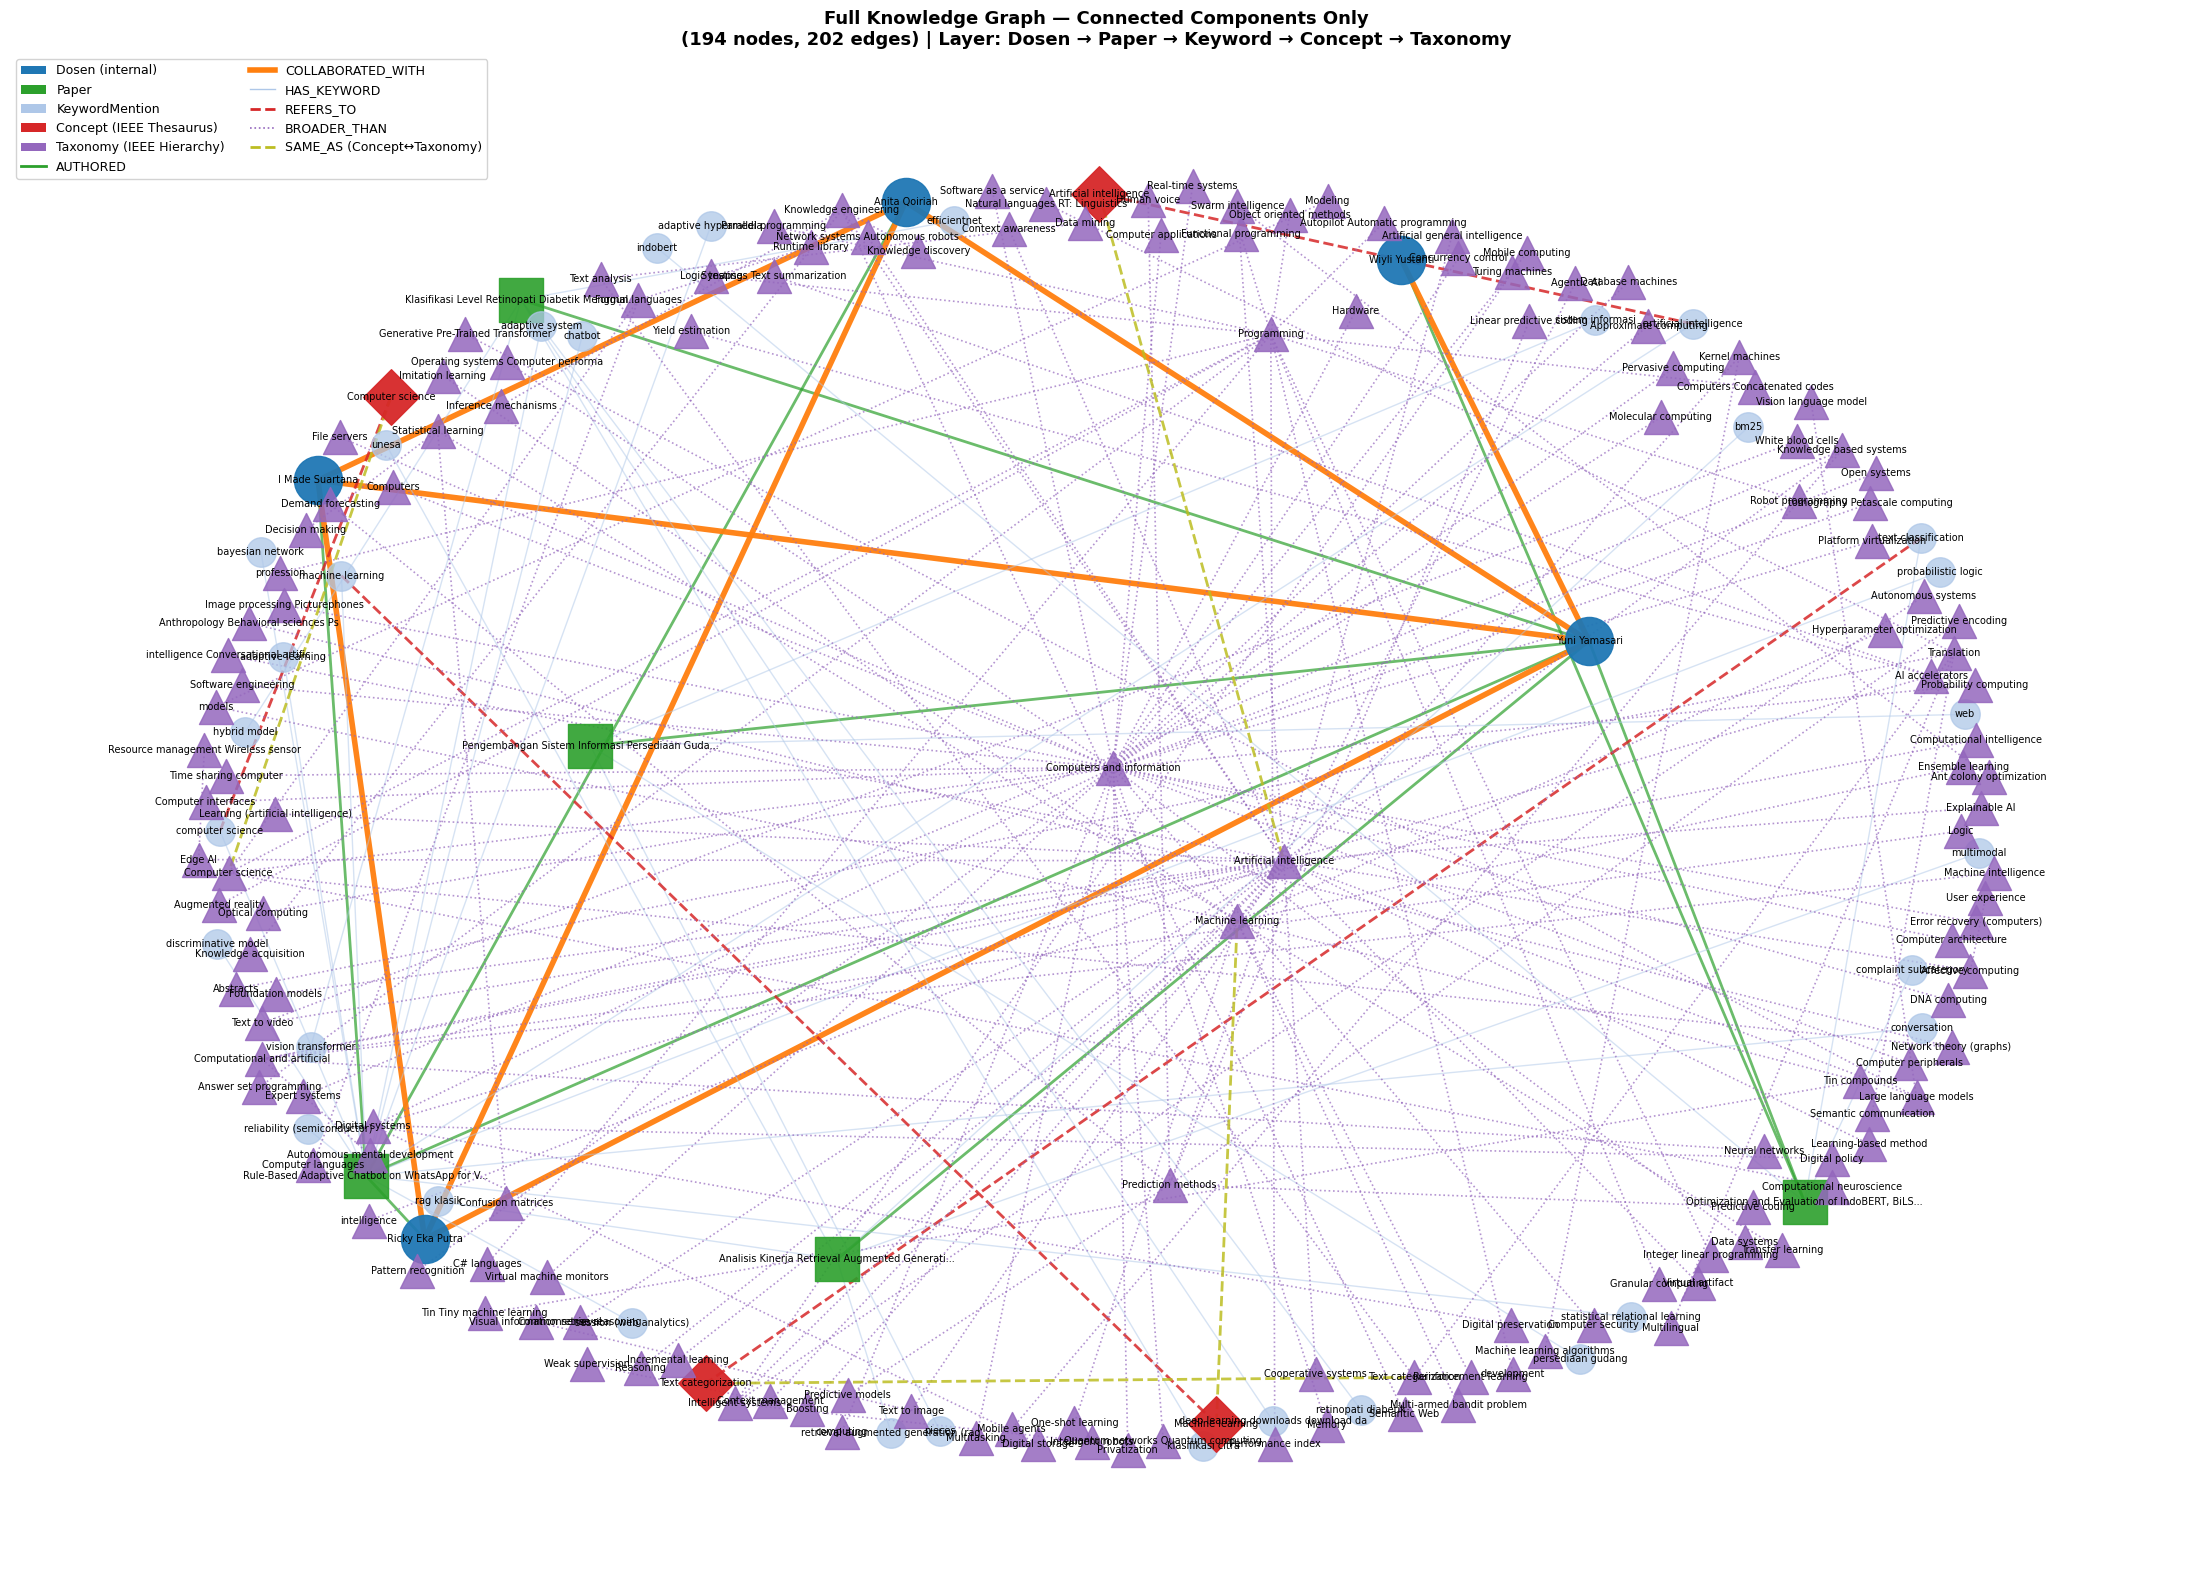

✅ Saved: full_kg_visualization.png


In [33]:
# ─── CELL F-REBUILD ── Visualisasi Full KG ────────────────────────────────────
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ── Pisah node per type ───────────────────────────────────────────────────────
dosen_nodes    = [n for n, d in G.nodes(data=True) if d.get("type") == "Dosen"]
paper_nodes    = [n for n, d in G.nodes(data=True) if d.get("type") == "Paper"]
kw_nodes       = [n for n, d in G.nodes(data=True) if d.get("type") == "KeywordMention"]
concept_nodes  = [n for n, d in G.nodes(data=True) if d.get("type") == "Concept"]
taxonomy_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "Taxonomy"]

# ── Pisah edge per rel ────────────────────────────────────────────────────────
authored_edges  = [(u,v) for u,v,d in G.edges(data=True) if d.get("rel") == "AUTHORED"]
collab_edges    = [(u,v) for u,v,d in G.edges(data=True) if d.get("rel") == "COLLABORATED_WITH"]
kw_edges        = [(u,v) for u,v,d in G.edges(data=True) if d.get("rel") == "HAS_KEYWORD"]
refers_edges    = [(u,v) for u,v,d in G.edges(data=True) if d.get("rel") == "REFERS_TO"]
broader_edges   = [(u,v) for u,v,d in G.edges(data=True) if d.get("rel") == "BROADER_THAN"]
sameas_edges    = [(u,v) for u,v,d in G.edges(data=True) if d.get("rel") == "SAME_AS"]

# ── Layout ────────────────────────────────────────────────────────────────────
# Pakai subgraph yang terhubung saja untuk vis yang lebih bersih
# (exclude isolated dosen yang belum punya paper)
connected_nodes = set()
for comp in nx.connected_components(G):
    if len(comp) > 1:          # skip isolated nodes
        connected_nodes |= comp

G_vis   = G.subgraph(connected_nodes).copy()
pos_vis = nx.spring_layout(G_vis, seed=42, k=2.8, iterations=80)
labels  = {n: d.get("label", n) for n, d in G_vis.nodes(data=True)}

# Filter node/edge lists ke subgraph
def in_vis(u, v=None):
    if v is None:
        return u in connected_nodes
    return u in connected_nodes and v in connected_nodes

dosen_v    = [n for n in dosen_nodes    if in_vis(n)]
paper_v    = [n for n in paper_nodes    if in_vis(n)]
kw_v       = [n for n in kw_nodes       if in_vis(n)]
concept_v  = [n for n in concept_nodes  if in_vis(n)]
taxonomy_v = [n for n in taxonomy_nodes if in_vis(n)]

authored_v  = [(u,v) for u,v in authored_edges  if in_vis(u,v)]
collab_v    = [(u,v) for u,v in collab_edges    if in_vis(u,v)]
kw_v_e      = [(u,v) for u,v in kw_edges        if in_vis(u,v)]
refers_v    = [(u,v) for u,v in refers_edges     if in_vis(u,v)]
broader_v   = [(u,v) for u,v in broader_edges   if in_vis(u,v)]
sameas_v    = [(u,v) for u,v in sameas_edges     if in_vis(u,v)]

fig, ax = plt.subplots(figsize=(22, 16))

# Nodes
nx.draw_networkx_nodes(G_vis, pos_vis, nodelist=dosen_v,
                        node_color="#1f77b4", node_size=1200,
                        alpha=0.95, ax=ax)
nx.draw_networkx_nodes(G_vis, pos_vis, nodelist=paper_v,
                        node_color="#2ca02c", node_shape="s",
                        node_size=1000, alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G_vis, pos_vis, nodelist=kw_v,
                        node_color="#aec7e8", node_size=450,
                        alpha=0.75, ax=ax)
nx.draw_networkx_nodes(G_vis, pos_vis, nodelist=concept_v,
                        node_color="#d62728", node_shape="D",
                        node_size=800, alpha=0.95, ax=ax)
nx.draw_networkx_nodes(G_vis, pos_vis, nodelist=taxonomy_v,
                        node_color="#9467bd", node_shape="^",
                        node_size=600, alpha=0.85, ax=ax)

# Edges
nx.draw_networkx_edges(G_vis, pos_vis, edgelist=authored_v,
                        edge_color="#2ca02c", width=2.0,
                        style="solid", alpha=0.7, ax=ax)
nx.draw_networkx_edges(G_vis, pos_vis, edgelist=collab_v,
                        edge_color="#ff7f0e", width=4.0,
                        style="solid", alpha=0.95, ax=ax)
nx.draw_networkx_edges(G_vis, pos_vis, edgelist=kw_v_e,
                        edge_color="#aec7e8", width=1.0,
                        style="solid", alpha=0.5, ax=ax)
nx.draw_networkx_edges(G_vis, pos_vis, edgelist=refers_v,
                        edge_color="#d62728", width=2.0,
                        style="dashed", alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_vis, pos_vis, edgelist=broader_v,
                        edge_color="#9467bd", width=1.2,
                        style="dotted", alpha=0.7, ax=ax)
nx.draw_networkx_edges(G_vis, pos_vis, edgelist=sameas_v,
                        edge_color="#bcbd22", width=2.0,
                        style="dashed", alpha=0.85, ax=ax)

# Labels
nx.draw_networkx_labels(G_vis, pos_vis, labels=labels,
                         font_size=7, ax=ax)

# Legend
legend_elements = [
    Patch(facecolor="#1f77b4", label="Dosen (internal)"),
    Patch(facecolor="#2ca02c", label="Paper"),
    Patch(facecolor="#aec7e8", label="KeywordMention"),
    Patch(facecolor="#d62728", label="Concept (IEEE Thesaurus)"),
    Patch(facecolor="#9467bd", label="Taxonomy (IEEE Hierarchy)"),
    Line2D([0],[0], color="#2ca02c", lw=2,   linestyle="-",  label="AUTHORED"),
    Line2D([0],[0], color="#ff7f0e", lw=4,   linestyle="-",  label="COLLABORATED_WITH"),
    Line2D([0],[0], color="#aec7e8", lw=1,   linestyle="-",  label="HAS_KEYWORD"),
    Line2D([0],[0], color="#d62728", lw=2,   linestyle="--", label="REFERS_TO"),
    Line2D([0],[0], color="#9467bd", lw=1.2, linestyle=":",  label="BROADER_THAN"),
    Line2D([0],[0], color="#bcbd22", lw=2,   linestyle="--", label="SAME_AS (Concept↔Taxonomy)"),
]
ax.legend(handles=legend_elements, loc="upper left",
          fontsize=9, framealpha=0.85, ncol=2)

ax.set_title(
    f"Full Knowledge Graph — Connected Components Only\n"
    f"({G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges) "
    f"| Layer: Dosen → Paper → Keyword → Concept → Taxonomy",
    fontsize=13, fontweight="bold"
)
ax.axis("off")
plt.tight_layout()
plt.savefig("full_kg_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: full_kg_visualization.png")

In [34]:
# ─── CELL G-REBUILD ── KG Statistics ─────────────────────────────────────────
from collections import Counter

print("=" * 55)
print("  KNOWLEDGE GRAPH STATISTICS")
print("=" * 55)

type_count = Counter(d.get("type","?") for _, d in G.nodes(data=True))
rel_count  = Counter(d.get("rel","?")  for _, _, d in G.edges(data=True))

print("\n📦 NODE TYPES:")
for t, c in sorted(type_count.items(), key=lambda x: -x[1]):
    bar = "█" * (c // 2)
    print(f"   {t:22s} → {c:4d}  {bar}")

print("\n🔗 EDGE TYPES (RELATIONSHIPS):")
for r, c in sorted(rel_count.items(), key=lambda x: -x[1]):
    bar = "█" * (c // 1)
    print(f"   {r:27s} → {c:4d}  {bar}")

print(f"\n🌐 Graph density         : {nx.density(G):.6f}")
print(f"🔗 Connected components  : {nx.number_connected_components(G)}")

# Komponen > 1 node (exclude isolated)
non_isolated = [c for c in nx.connected_components(G) if len(c) > 1]
print(f"📎 Non-isolated components: {len(non_isolated)}")
print(f"👥 Nodes dalam non-isolated: {sum(len(c) for c in non_isolated)}")

# Top dosen by kolaborasi
if len(collab_internal) > 0:
    print("\n🏆 Top Dosen by Collaboration:")
    collab_counts = (
        pd.concat([
            collab_internal[["nama_a"]].rename(columns={"nama_a": "nama"}),
            collab_internal[["nama_b"]].rename(columns={"nama_b": "nama"})
        ])
        .value_counts()
        .head(10)
    )
    print(collab_counts.to_string())

# Top paper by keyword count
print("\n📄 Top Paper by Keyword Count:")
kw_per_paper = df_keyword_mentions_mapped.groupby("paper_id").size().sort_values(ascending=False)
for pid, cnt in kw_per_paper.head(5).items():
    title = df_papers[df_papers["paper_id"] == pid]["title"].values
    title_str = title[0][:50] + "..." if len(title) > 0 else pid
    print(f"   {cnt} keywords  →  {title_str}")

# Concept coverage
print(f"\n🎯 Keyword → Concept coverage:")
total_kw  = len(df_keyword_mentions_mapped)
mapped_kw = df_keyword_mentions_mapped["concept_uri"].notna().sum()
print(f"   {mapped_kw}/{total_kw} keywords mapped ke IEEE Concept "
      f"({mapped_kw/total_kw*100:.1f}%)")

# Path example: Dosen → Paper → Keyword → Concept → Taxonomy
print("\n🔍 Contoh jalur lengkap (Dosen → Taxonomy):")
for _, mrow in matched.iterrows():
    d_node = f"D:{mrow['nip']}"
    p_node = f"P:{mrow['paper_id']}"
    kws    = [n for n in G.neighbors(p_node)
              if G.nodes[n].get("type") == "KeywordMention"]
    for kw in kws:
        concepts = [n for n in G.neighbors(kw)
                    if G.nodes[n].get("type") == "Concept"]
        for c in concepts:
            taxes = [n for n in G.neighbors(c)
                     if G.nodes[n].get("type") in ("Taxonomy", "Concept")]
            if taxes:
                d_label  = G.nodes[d_node].get("label","?")
                p_label  = G.nodes[p_node].get("label","?")[:30]
                kw_label = G.nodes[kw].get("label","?")
                c_label  = G.nodes[c].get("label","?")
                t_label  = G.nodes[taxes[0]].get("label","?")
                print(f"   {d_label}")
                print(f"   └─AUTHORED──► {p_label}...")
                print(f"                └─HAS_KEYWORD──► {kw_label}")
                print(f"                                 └─REFERS_TO──► {c_label}")
                print(f"                                                └─BROADER──► {t_label}")
                print()

  KNOWLEDGE GRAPH STATISTICS

📦 NODE TYPES:
   Taxonomy               →  148  ██████████████████████████████████████████████████████████████████████████
   Dosen                  →  129  ████████████████████████████████████████████████████████████████
   KeywordMention         →   32  ████████████████
   Paper                  →    5  ██
   Concept                →    4  ██

🔗 EDGE TYPES (RELATIONSHIPS):
   BROADER_THAN                →  146  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   HAS_KEYWORD                 →   32  ████████████████████████████████
   AUTHORED                    →    9  █████████
   COLLABORATED_WITH           →    7  ███████
   REFERS_TO                   →    4  ████
   SAME_AS                     →    4  ████

🌐 Graph density         : 0.004008
🔗 Connected components  : 125
📎 Non-isolated components: 1
👥 Nodes dalam non-isolated: 194

🏆 Top Dosen by Collabo

In [31]:
from rdflib import Graph
from rdflib.namespace import SKOS, RDF

g_tax = Graph()
g_tax.parse("ieee-taxonomy.ttl", format="turtle")
print(f"Taxonomy triples: {len(g_tax)}")

Taxonomy triples: 8548


In [34]:
# Cek berapa triple dan predicate apa saja yang ada
g_tax = Graph()
g_tax.parse("ieee-taxonomy.ttl", format="turtle")
print(f"Total triples: {len(g_tax)}")

# Cek semua predicate yang dipakai
predicates = set(g_tax.predicates())
print(f"\nPredicates yang ditemukan ({len(predicates)}):")
for p in sorted(predicates):
    print(f"  {p}")


Total triples: 8548

Predicates yang ditemukan (3):
  http://www.w3.org/1999/02/22-rdf-syntax-ns#type
  http://www.w3.org/2000/01/rdf-schema#label
  http://www.w3.org/2000/01/rdf-schema#subClassOf


In [35]:
# Lihat 20 triple pertama apa adanya
print("Sample triples dari ieee-taxonomy.ttl:")
for i, (s, p, o) in enumerate(g_tax):
    print(f"  S: {str(s)[:80]}")
    print(f"  P: {str(p)}")
    print(f"  O: {str(o)[:80]}")
    print()
    if i >= 19:
        break


Sample triples dari ieee-taxonomy.ttl:
  S: https://ieee-taxonomy.org/diamond-like_carbon_
  P: http://www.w3.org/2000/01/rdf-schema#label
  O: diamond-like carbon 

  S: https://ieee-taxonomy.org/artificial_neural_networks_
  P: http://www.w3.org/1999/02/22-rdf-syntax-ns#type
  O: https://ieee-taxonomy.org/schema#Topic

  S: https://ieee-taxonomy.org/acoustooptic_effects_............biomedical_acoustics_
  P: http://www.w3.org/2000/01/rdf-schema#label
  O: acoustooptic effects ............biomedical acoustics 

  S: https://ieee-taxonomy.org/nearest_neighbor_methods_........pattern_matching_....
  P: http://www.w3.org/1999/02/22-rdf-syntax-ns#type
  O: https://ieee-taxonomy.org/schema#Topic

  S: https://ieee-taxonomy.org/quantum_information_science_............quantum_key_di
  P: http://www.w3.org/1999/02/22-rdf-syntax-ns#type
  O: https://ieee-taxonomy.org/schema#Topic

  S: https://ieee-taxonomy.org/media_............fake_news_............nonhomogeneous
  P: http://www.w3.org/2000/

In [36]:
from rdflib.namespace import SKOS, RDF, OWL, RDFS

# Hitung berapa banyak tiap tipe relasi SKOS
checks = {
    "skos:Concept"  : (RDF.type, SKOS.Concept),
    "skos:broader"  : SKOS.broader,
    "skos:narrower" : SKOS.narrower,
    "skos:related"  : SKOS.related,
    "skos:prefLabel": SKOS.prefLabel,
    "skos:altLabel" : SKOS.altLabel,
    "rdfs:subClassOf": RDFS.subClassOf,  # IEEE kadang pakai ini
    "owl:equivalentClass": OWL.equivalentClass,
}

for name, pred in checks.items():
    if isinstance(pred, tuple):
        count = len(list(g_tax.subjects(pred[0], pred[1])))
    else:
        count = len(list(g_tax.subject_objects(pred)))
    print(f"  {name}: {count}")


  skos:Concept: 0
  skos:broader: 0
  skos:narrower: 0
  skos:related: 0
  skos:prefLabel: 0
  skos:altLabel: 0
  rdfs:subClassOf: 1
  owl:equivalentClass: 0


In [38]:
from rdflib import Graph, Namespace
from rdflib.namespace import RDF, RDFS  # Perbaikan di sini: rdffs -> rdflib
import pandas as pd
import re

# Separator level di URI IEEE taxonomy
# ....     = 1 level up (parent)
# ........  = 2 level up (grandparent)
# ............ = 3 level up

def parse_ieee_uri_hierarchy(uri: str):
    """
    Parse URI IEEE taxonomy menjadi list path dari child ke root.
    Contoh:
      'nearest_neighbor_methods_........pattern_matching_'
      → ['nearest neighbor methods', 'pattern matching']
    """
    # ambil bagian path setelah domain
    path = uri.split("ieee-taxonomy.org/")[-1]
    path = path.rstrip("_").rstrip("/")

    # split berdasarkan pola titik (4 atau lebih titik sebagai separator)
    parts = re.split(r'\.{4,}', path)

    # bersihkan tiap bagian
    cleaned = []
    for part in parts:
        label = part.strip("_").replace("_", " ").strip()
        if label:
            cleaned.append(label)

    return cleaned  # index 0 = child paling spesifik, index -1 = parent paling umum

# Test
test_uris = [
    "https://ieee-taxonomy.org/nearest_neighbor_methods_........pattern_matching_",
    "https://ieee-taxonomy.org/utility_programs_....software_engineering_........capability_maturity_model_",
    "https://ieee-taxonomy.org/artificial_neural_networks_",
    "https://ieee-taxonomy.org/machine_learning_",
]

for uri in test_uris:
    path = parse_ieee_uri_hierarchy(uri)
    print(f"URI: .../{uri.split('/')[-1]}")
    print(f"Path: {' → '.join(path)}")
    print()


URI: .../nearest_neighbor_methods_........pattern_matching_
Path: nearest neighbor methods → pattern matching

URI: .../utility_programs_....software_engineering_........capability_maturity_model_
Path: utility programs → software engineering → capability maturity model

URI: .../artificial_neural_networks_
Path: artificial neural networks

URI: .../machine_learning_
Path: machine learning



In [39]:
from rdflib import URIRef

tax_records = []
node_records = []

for s in g_tax.subjects(RDF.type, URIRef("https://ieee-taxonomy.org/schema#Topic")):
    uri_str = str(s)
    path = parse_ieee_uri_hierarchy(uri_str)

    # ambil label dari rdfs:label kalau ada, fallback ke path[0]
    labels = list(g_tax.objects(s, RDFS.label))
    label_str = str(labels[0]).strip() if labels else (path[0] if path else uri_str)

    node_records.append({
        "uri"      : uri_str,
        "label"    : label_str,
        "path"     : path,
        "depth"    : len(path)
    })

    # bangun edge: tiap adjacent pair dalam path = parent-child
    # path[0] = child, path[1] = parent, path[2] = grandparent, dst.
    for i in range(len(path) - 1):
        child_label  = path[i]
        parent_label = path[i + 1]
        tax_records.append({
            "child_label" : child_label,
            "parent_label": parent_label,
            "child_uri"   : uri_str if i == 0 else f"ieee-taxonomy::{child_label}",
            "parent_uri"  : f"ieee-taxonomy::{parent_label}",
            "rel"         : "BROADER_THAN",
            "source_uri"  : uri_str
        })

df_tax_nodes = pd.DataFrame(node_records)
df_taxonomy_edges_full = pd.DataFrame(tax_records).drop_duplicates(
    subset=["child_label", "parent_label"]
)

print(f"Tax nodes : {len(df_tax_nodes)}")
print(f"Tax edges : {len(df_taxonomy_edges_full)}")
df_taxonomy_edges_full.head(10)


Tax nodes : 4273
Tax edges : 3385


,child_label,parent_label,child_uri,parent_uri,rel,source_uri
0,3g mobile communication,4g mobile communication,https://ieee-taxonomy.org/3g_mobile_communicat...,ieee-taxonomy::4g mobile communication,BROADER_THAN,https://ieee-taxonomy.org/3g_mobile_communicat...
1,6g mobile communication,ambient networks,https://ieee-taxonomy.org/6g_mobile_communicat...,ieee-taxonomy::ambient networks,BROADER_THAN,https://ieee-taxonomy.org/6g_mobile_communicat...
2,dielectrics,dielectric constant,https://ieee-taxonomy.org/_....dielectrics_......,ieee-taxonomy::dielectric constant,BROADER_THAN,https://ieee-taxonomy.org/_....dielectrics_......
3,dielectric constant,high-k gate dielectrics,ieee-taxonomy::dielectric constant,ieee-taxonomy::high-k gate dielectrics,BROADER_THAN,https://ieee-taxonomy.org/_....dielectrics_......
4,marine navigation,marine technology,https://ieee-taxonomy.org/_....marine_navigati...,ieee-taxonomy::marine technology,BROADER_THAN,https://ieee-taxonomy.org/_....marine_navigati...
5,marine technology,marine equipment,ieee-taxonomy::marine technology,ieee-taxonomy::marine equipment,BROADER_THAN,https://ieee-taxonomy.org/_....marine_navigati...
6,marine equipment,marine transportation,ieee-taxonomy::marine equipment,ieee-taxonomy::marine transportation,BROADER_THAN,https://ieee-taxonomy.org/_....marine_navigati...
7,power electronics,converters,https://ieee-taxonomy.org/_power_electronics__...,ieee-taxonomy::converters,BROADER_THAN,https://ieee-taxonomy.org/_power_electronics__...
8,abstracts,text summarization,https://ieee-taxonomy.org/abstracts_.............,ieee-taxonomy::text summarization,BROADER_THAN,https://ieee-taxonomy.org/abstracts_.............
9,text summarization,bibliographies,ieee-taxonomy::text summarization,ieee-taxonomy::bibliographies,BROADER_THAN,https://ieee-taxonomy.org/abstracts_.............


In [41]:
import re
from rdflib import Graph, URIRef
from rdflib.namespace import RDF, RDFS

# ── Re-define fungsi normalize (self-contained agar tidak bergantung urutan cell) ──
def normalize_keyword(text: str) -> str:
    if text is None:
        return ""
    t = text.lower().strip()
    t = re.sub(r"\s+", " ", t)
    t = t.strip(" .;:,")
    return t

MANUAL_CANONICAL = {
    "knowledge graphs"              : "knowledge graph",
    "knowledge-graph"               : "knowledge graph",
    "neural networks"               : "neural network",
    "convolutional neural networks" : "convolutional neural network",
    "graph neural networks"         : "graph neural network",
    "large language models"         : "large language model",
    "transformers"                  : "transformer",
    "language models"               : "language model",
    "ml"                            : "machine learning",
    "dl"                            : "deep learning",
    "nlp"                           : "natural language processing",
    "cnn"                           : "convolutional neural network",
    "rnn"                           : "recurrent neural network",
    "lstm"                          : "long short-term memory",
    "gnn"                           : "graph neural network",
    "kg"                            : "knowledge graph",
    "ai"                            : "artificial intelligence",
    "ner"                           : "named entity recognition",
    "llm"                           : "large language model",
    "svm"                           : "support vector machines",
    "pembelajaran mesin"            : "machine learning",
    "pembelajaran mendalam"         : "deep learning",
    "graf pengetahuan"              : "knowledge graph",
    "jaringan syaraf tiruan"        : "neural network",
    "pengolahan bahasa alami"       : "natural language processing",
    "kecerdasan buatan"             : "artificial intelligence",
    "klasifikasi teks"              : "text classification",
    "text classification"           : "text classification",
    "named entity recognition"      : "named entity recognition",
    "relation extraction"           : "relationship extraction",
    "information extraction"        : "information extraction",
    "information retrieval"         : "information retrieval",
    "sentiment analysis"            : "sentiment analysis",
    "knowledge base"                : "knowledge base",
    "knowledge representation"      : "knowledge representation",
    "word embeddings"               : "word embedding",
    "graph embedding"               : "graph embedding",
    "link prediction"               : "link prediction",
    "community detection"           : "community detection",
}

def normalize_with_canonical(text: str) -> str:
    n = normalize_keyword(text)
    return MANUAL_CANONICAL.get(n, n)

# ── Build label → uri lookup dari taxonomy nodes ──────────────────────────────
tax_label_index = {}

for _, row in df_tax_nodes.iterrows():
    norm = normalize_with_canonical(row["label"])
    tax_label_index[norm] = row["uri"]

    # index juga semua path parts (parent/grandparent labels)
    for part in row["path"]:
        pnorm = normalize_with_canonical(part)
        if pnorm not in tax_label_index:
            tax_label_index[pnorm] = f"ieee-taxonomy::{part}"

print(f"Taxonomy label index size: {len(tax_label_index)}")

# ── Cek concept yang sudah dipakai keyword paper ──────────────────────────────
print("\nCek concept yang terpakai vs taxonomy:")
for _, row in df_concepts_used.iterrows():
    uri   = row["concept_uri"]
    label = str(row["pref_label"]).lower().strip() if pd.notna(row["pref_label"]) else ""
    norm  = normalize_with_canonical(label)
    found = norm in tax_label_index
    print(f"  {'✅' if found else '❌'} '{label}' → {'found' if found else 'NOT found in taxonomy'}")


Taxonomy label index size: 7912

Cek concept yang terpakai vs taxonomy:
  ❌ 'text categorization' → NOT found in taxonomy
  ✅ 'computer science' → found
  ✅ 'machine learning' → found
  ✅ 'artificial intelligence' → found


In [43]:
# Semua label yang terpakai dari concept paper (dari thesaurus)
used_labels_norm = set()
for _, row in df_concepts_used.iterrows():
    if pd.notna(row["pref_label"]):
        used_labels_norm.add(normalize_with_canonical(str(row["pref_label"])))

print(f"Used labels (normalized): {used_labels_norm}")

# Normalize semua label di taxonomy edges
df_tax_norm = df_taxonomy_edges_full.copy()
df_tax_norm["child_norm"]  = df_tax_norm["child_label"].apply(normalize_with_canonical)
df_tax_norm["parent_norm"] = df_tax_norm["parent_label"].apply(normalize_with_canonical)

# Level 1: edges yang child atau parent-nya match ke used labels
direct_edges = df_tax_norm[
    df_tax_norm["child_norm"].isin(used_labels_norm) |
    df_tax_norm["parent_norm"].isin(used_labels_norm)
]

print(f"\nDirect edges (level 1): {len(direct_edges)}")
if len(direct_edges) > 0:
    print(direct_edges[["child_label", "parent_label", "rel"]].to_string())


Used labels (normalized): {'artificial intelligence', 'computer science', 'machine learning', 'text categorization'}

Direct edges (level 1): 1
          child_label                parent_label           rel
678  computer science  computational neuroscience  BROADER_THAN


In [44]:
# Cek satu per satu apakah used_labels ada di taxonomy label index
print("Cek manual keberadaan label di taxonomy index:")
for label in used_labels_norm:
    in_index = label in tax_label_index
    print(f"  {'✅' if in_index else '❌'} '{label}'")

print()

# Cari label taxonomy yang paling dekat secara substring
print("Taxonomy labels yang mengandung kata kunci:")
keywords_to_check = ["machine learning", "artificial intelligence", 
                     "text", "classification", "categorization", "computer"]

for kw in keywords_to_check:
    matches = [
        row["child_label"] for _, row in df_tax_norm.iterrows()
        if kw in str(row["child_label"]).lower()
    ][:5]
    if matches:
        print(f"\n  '{kw}' ditemukan di:")
        for m in matches:
            print(f"    - {m}")


Cek manual keberadaan label di taxonomy index:
  ✅ 'artificial intelligence'
  ✅ 'computer science'
  ✅ 'machine learning'
  ❌ 'text categorization'

Taxonomy labels yang mengandung kata kunci:

  'machine learning' ditemukan di:
    - adversarial machine learning
    - automated machine learning
    - machine learning algorithms
    - tiny machine learning

  'artificial intelligence' ditemukan di:
    - learning %28artificial intelligence%29

  'text' ditemukan di:
    - text summarization
    - context awareness
    - textile electrodes
    - hypertext systems
    - smart textiles

  'classification' ditemukan di:
    - classification algorithms

  'computer' ditemukan di:
    - computer generated music
    - analog computers
    - human computer interaction
    - computer industry
    - computer science education


In [45]:
# Lihat sample path dari df_tax_nodes untuk cek format label
print("Sample path dari taxonomy nodes (50 pertama dengan depth > 1):")
multi_level = df_tax_nodes[df_tax_nodes["depth"] > 1].head(50)
for _, row in multi_level.iterrows():
    print(f"  {' → '.join(row['path'])}")


Sample path dari taxonomy nodes (50 pertama dengan depth > 1):
  3g mobile communication → 4g mobile communication
  6g mobile communication → ambient networks
  dielectrics → dielectric constant → high-k gate dielectrics
  marine navigation → marine technology → marine equipment → marine transportation
  power electronics → converters
  abstracts → text summarization → bibliographies → biographies → autobiographies
  ac-dc power converters → dc-ac power converters
  ac motors → brushless motors → commutation
  accelerated aging → acoustic testing
  access → frequency division multiaccess → multicarrier code division multiple access → subscriber loops
  accidents → aerospace accidents → electrical accidents
  acidosis → acute respiratory distress syndrome
  acoustic devices → acoustic emission → acoustic field
  acoustic distortion → four-wave mixing
  acoustic measurements → antenna measurements
  acoustic phonetics → acoustic propagation
  acoustic transducers → biomedical transducer

In [46]:
# Baca raw 100 baris pertama untuk cek format asli
with open("ieee-taxonomy.ttl", "r", encoding="utf-8") as f:
    lines = f.readlines()

print(f"Total baris: {len(lines)}")
print("\n--- 60 baris pertama ---")
for i, line in enumerate(lines[:60]):
    print(f"{i+1:4d}: {line}", end="")

print("\n\n--- Cari baris yang mengandung 'machine' ---")
for i, line in enumerate(lines):
    if "machine" in line.lower():
        print(f"{i+1:4d}: {line}", end="")
        if i > 0: print(f"      prev: {lines[i-1]}", end="")
        print()


Total baris: 12827

--- 60 baris pertama ---
   1: @prefix ieee: <https://ieee-taxonomy.org/> .
   2: @prefix owl: <http://www.w3.org/2002/07/owl#> .
   3: @prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
   4: @prefix skos: <http://www.w3.org/2004/02/skos/core#> .
   5: 
   6: ieee: a <https://ieee-taxonomy.org/schema#Topic> ;
   7:     rdfs:label "" .
   8: 
   9: <https://ieee-taxonomy.org/%28ieee%29_> a <https://ieee-taxonomy.org/schema#Topic> ;
  10:     rdfs:label "(ieee) " .
  11: 
  12: ieee:1.05_ a <https://ieee-taxonomy.org/schema#Topic> ;
  13:     rdfs:label "1.05 " .
  14: 
  15: ieee:2-dof_ a <https://ieee-taxonomy.org/schema#Topic> ;
  16:     rdfs:label "2-dof " .
  17: 
  18: ieee:3-dof_ a <https://ieee-taxonomy.org/schema#Topic> ;
  19:     rdfs:label "3-dof " .
  20: 
  21: ieee:3g_mobile_communication_............4g_mobile_communication_ a <https://ieee-taxonomy.org/schema#Topic> ;
  22:     rdfs:label "3g mobile communication ............4g mobile communicat

In [48]:
import re
import pandas as pd
from rdflib import Graph, URIRef
from rdflib.namespace import RDF, RDFS

# ── Fungsi utama: parse satu label menjadi (child_label, parent_label) ────────
# Format label IEEE: "child ........parent ....grandparent "
# Rules:
# - Paling kiri = most specific (child)
# - Makin ke kanan = makin umum (parent)
# - 4 dots = 1 level, 8 dots = 2 levels, 12 dots = 3 levels

def parse_label_to_edges(label: str):
    """
    Parse label IEEE taxonomy menjadi list edge (child, parent).
    Label: "deep learning ........machine learning ....artificial intelligence "
    → [("deep learning", "machine learning"),
       ("machine learning", "artificial intelligence")]
    """
    label = label.strip()

    # split berdasarkan 4+ titik berurutan, pertahankan separator
    parts = re.split(r'(\.{4,})', label)

    # rekonstruksi: [term, sep, term, sep, term, ...]
    # pisahkan jadi list (term, level) berdasarkan jumlah titik sebelumnya
    terms = []
    i = 0
    while i < len(parts):
        part = parts[i].strip()
        if part and not re.match(r'^\.+$', part):
            # cari separator sebelumnya
            if i > 0 and re.match(r'^\.+$', parts[i-1]):
                dots = len(parts[i-1].strip())
                level = dots // 4
            else:
                level = 0
            terms.append((part, level))
        i += 1

    # build edges: tiap term dengan level > 0 punya parent di level sebelumnya
    edges = []
    for i in range(len(terms) - 1):
        child_term, child_level  = terms[i]
        parent_term, parent_level = terms[i + 1]
        edges.append({
            "child_label" : child_term,
            "parent_label": parent_term,
            "child_level" : child_level,
            "parent_level": parent_level
        })

    return terms, edges

# Test dengan contoh dari PDF
test_labels = [
    "machine learning ",
    "deep learning ........machine learning ....artificial intelligence ",
    "adversarial machine learning ............association rule learning ............attention mechanisms ............automated machine learning ",
    "text categorization ........text analysis ....information retrieval ",
    "knowledge representation ........artificial intelligence ",
    "natural language processing ........artificial intelligence ",
]

print("Test parse:")
for lbl in test_labels:
    terms, edges = parse_label_to_edges(lbl)
    print(f"\n  Label: '{lbl.strip()}'")
    print(f"  Terms: {[(t, l) for t, l in terms]}")
    print(f"  Edges: {[(e['child_label'], '→', e['parent_label']) for e in edges]}")


Test parse:

  Label: 'machine learning'
  Terms: [('machine learning', 0)]
  Edges: []

  Label: 'deep learning ........machine learning ....artificial intelligence'
  Terms: [('deep learning', 0), ('machine learning', 2), ('artificial intelligence', 1)]
  Edges: [('deep learning', '→', 'machine learning'), ('machine learning', '→', 'artificial intelligence')]

  Label: 'adversarial machine learning ............association rule learning ............attention mechanisms ............automated machine learning'
  Terms: [('adversarial machine learning', 0), ('association rule learning', 3), ('attention mechanisms', 3), ('automated machine learning', 3)]
  Edges: [('adversarial machine learning', '→', 'association rule learning'), ('association rule learning', '→', 'attention mechanisms'), ('attention mechanisms', '→', 'automated machine learning')]

  Label: 'text categorization ........text analysis ....information retrieval'
  Terms: [('text categorization', 0), ('text analysis', 2), (

In [49]:
tax_records  = []
node_records = []

for s in g_tax.subjects(RDF.type, URIRef("https://ieee-taxonomy.org/schema#Topic")):
    uri_str = str(s)
    labels_list = list(g_tax.objects(s, RDFS.label))
    if not labels_list:
        continue

    label_raw = str(labels_list[0])
    terms, edges = parse_label_to_edges(label_raw)

    if not terms:
        continue

    # node utama = term paling kiri (most specific)
    main_label = terms[0][0]
    node_records.append({
        "uri"        : uri_str,
        "label"      : main_label,
        "full_label" : label_raw.strip(),
        "depth"      : len(terms),
        "path"       : [t for t, l in terms]
    })

    # tambah semua edges dari label ini
    for edge in edges:
        tax_records.append({
            "child_label" : edge["child_label"],
            "parent_label": edge["parent_label"],
            "child_level" : edge["child_level"],
            "parent_level": edge["parent_level"],
            "rel"         : "BROADER_THAN",
            "source_uri"  : uri_str
        })

df_tax_nodes = pd.DataFrame(node_records)
df_taxonomy_edges_full = (
    pd.DataFrame(tax_records)
    .drop_duplicates(subset=["child_label", "parent_label"])
    .reset_index(drop=True)
)

print(f"Tax nodes : {len(df_tax_nodes)}")
print(f"Tax edges : {len(df_taxonomy_edges_full)}")
print()
print("Sample edges relevan (cari machine learning, AI):")
mask = (
    df_taxonomy_edges_full["child_label"].str.contains("machine learning|artificial|deep learning|knowledge|natural language", case=False, na=False) |
    df_taxonomy_edges_full["parent_label"].str.contains("machine learning|artificial|deep learning|knowledge|natural language", case=False, na=False)
)
print(df_taxonomy_edges_full[mask][["child_label", "parent_label", "rel"]].to_string())


Tax nodes : 4271
Tax edges : 3385

Sample edges relevan (cari machine learning, AI):
                             child_label                        parent_label           rel
80          adversarial machine learning           association rule learning  BROADER_THAN
82                  attention mechanisms          automated machine learning  BROADER_THAN
210      artificial bee colony algorithm          backpropagation algorithms  BROADER_THAN
211         artificial biological organs                    artificial limbs  BROADER_THAN
255           automated machine learning                   automated parking  BROADER_THAN
583                   intelligent robots             knowledge based systems  BROADER_THAN
644                        concept drift                       deep learning  BROADER_THAN
1256  generative pre-trained transformer  learning (artificial intelligence)  BROADER_THAN
1257  learning (artificial intelligence)                   distance learning  BROADER_THAN
1645 

In [50]:
from rdflib import URIRef
from rdflib.namespace import RDF, RDFS

tax_records  = []
node_records = []

for s in g_tax.subjects(RDF.type, URIRef("https://ieee-taxonomy.org/schema#Topic")):
    uri_str = str(s)
    labels_list = list(g_tax.objects(s, RDFS.label))
    if not labels_list:
        continue

    label_raw = str(labels_list[0])
    terms, edges = parse_label_to_edges(label_raw)

    if not terms:
        continue

    main_label = terms[0][0]
    node_records.append({
        "uri"        : uri_str,
        "label"      : main_label,
        "full_label" : label_raw.strip(),
        "depth"      : len(terms),
        "path"       : [t for t, l in terms]
    })

    for edge in edges:
        tax_records.append({
            "child_label" : edge["child_label"],
            "parent_label": edge["parent_label"],
            "rel"         : "BROADER_THAN",
            "source_uri"  : uri_str
        })

df_tax_nodes = pd.DataFrame(node_records)
df_taxonomy_edges_full = (
    pd.DataFrame(tax_records)
    .drop_duplicates(subset=["child_label", "parent_label"])
    .reset_index(drop=True)
)

print(f"Tax nodes : {len(df_tax_nodes)}")
print(f"Tax edges : {len(df_taxonomy_edges_full)}")

# Sanity check: cari edge yang relevan dengan domain paper kamu
mask = (
    df_taxonomy_edges_full["child_label"].str.contains(
        "machine learning|artificial intelligence|deep learning|knowledge|natural language|text categor|neural network",
        case=False, na=False
    ) |
    df_taxonomy_edges_full["parent_label"].str.contains(
        "machine learning|artificial intelligence|deep learning|knowledge|natural language|text categor|neural network",
        case=False, na=False
    )
)
print(f"\nEdges relevan domain: {mask.sum()}")
print(df_taxonomy_edges_full[mask][["child_label", "parent_label", "rel"]].to_string())


Tax nodes : 4271
Tax edges : 3385

Edges relevan domain: 33
                             child_label                        parent_label           rel
80          adversarial machine learning           association rule learning  BROADER_THAN
82                  attention mechanisms          automated machine learning  BROADER_THAN
255           automated machine learning                   automated parking  BROADER_THAN
466             cellular neural networks         feedforward neural networks  BROADER_THAN
467          feedforward neural networks           extreme learning machines  BROADER_THAN
469               multilayer perceptrons               graph neural networks  BROADER_THAN
583                   intelligent robots             knowledge based systems  BROADER_THAN
644                        concept drift                       deep learning  BROADER_THAN
761                       huffman coding          neural network compression  BROADER_THAN
884                 fuzzy cogn

In [51]:
# Concept dari keyword paper yang sudah termap ke IEEE thesaurus
used_pref_labels = set()
for _, row in df_concepts_used.iterrows():
    if pd.notna(row["pref_label"]):
        used_pref_labels.add(str(row["pref_label"]).lower().strip())

print(f"Used concept labels: {used_pref_labels}")

# Normalize taxonomy edges untuk matching
df_tax_norm = df_taxonomy_edges_full.copy()
df_tax_norm["child_norm"]  = df_tax_norm["child_label"].str.lower().str.strip()
df_tax_norm["parent_norm"] = df_tax_norm["parent_label"].str.lower().str.strip()

# Level 1: edges yang langsung melibatkan concept terpakai
direct_edges = df_tax_norm[
    df_tax_norm["child_norm"].isin(used_pref_labels) |
    df_tax_norm["parent_norm"].isin(used_pref_labels)
].copy()

print(f"\nDirect edges (level 1): {len(direct_edges)}")
if len(direct_edges) > 0:
    print(direct_edges[["child_label", "parent_label", "rel"]].to_string())

# Level 2: tambah satu hop dari parent level 1
parent_labels_l1 = set(direct_edges["parent_norm"].tolist())
second_hop = df_tax_norm[
    df_tax_norm["child_norm"].isin(parent_labels_l1) |
    df_tax_norm["parent_norm"].isin(parent_labels_l1)
].copy()

df_taxonomy_filtered = (
    pd.concat([direct_edges, second_hop])
    .drop_duplicates(subset=["child_label", "parent_label"])
    .reset_index(drop=True)
)

print(f"\nTaxonomy edges relevan (2-hop): {len(df_taxonomy_filtered)}")
print(df_taxonomy_filtered[["child_label", "parent_label", "rel"]].to_string())


Used concept labels: {'artificial intelligence', 'computer science', 'machine learning', 'text categorization'}

Direct edges (level 1): 1
          child_label                parent_label           rel
642  computer science  computational neuroscience  BROADER_THAN

Taxonomy edges relevan (2-hop): 3
                  child_label                parent_label           rel
0            computer science  computational neuroscience  BROADER_THAN
1      cognitive neuroscience  computational neuroscience  BROADER_THAN
2  computational neuroscience     functional connectivity  BROADER_THAN


In [52]:
# Semua URI/label yang muncul di taxonomy filtered
all_tax_labels = (
    set(df_taxonomy_filtered["child_label"].str.lower().str.strip().tolist()) |
    set(df_taxonomy_filtered["parent_label"].str.lower().str.strip().tolist())
)

# Concept yang sudah ada dari thesaurus (hasil match keyword paper)
existing_labels = set(
    df_concepts_used["pref_label"].str.lower().str.strip().tolist()
    if "pref_label" in df_concepts_used.columns else []
)

# Concept parent baru dari taxonomy yang belum ada di df_concepts_used
new_labels = all_tax_labels - existing_labels

# Build DataFrame concept parent baru
new_concept_records = []
for lbl in new_labels:
    # cari di df_tax_nodes
    match = df_tax_nodes[df_tax_nodes["label"].str.lower().str.strip() == lbl]
    uri = match["uri"].values[0] if len(match) > 0 else f"ieee-taxonomy::{lbl.replace(' ', '_')}"
    new_concept_records.append({
        "concept_uri" : uri,
        "pref_label"  : lbl,
        "source"      : "ieee-taxonomy-parent"
    })

df_concepts_parent = pd.DataFrame(new_concept_records)

# Gabungkan semua concept nodes
df_concepts_all = pd.concat([
    df_concepts_used[["concept_uri", "pref_label"]].assign(source="ieee-thesaurus"),
    df_concepts_parent[["concept_uri", "pref_label", "source"]]
]).drop_duplicates(subset=["pref_label"]).reset_index(drop=True)

print(f"Concepts dari thesaurus (keyword paper): {len(df_concepts_used)}")
print(f"Concepts parent baru dari taxonomy     : {len(df_concepts_parent)}")
print(f"Total concept nodes                    : {len(df_concepts_all)}")
print()
df_concepts_all


Concepts dari thesaurus (keyword paper): 4
Concepts parent baru dari taxonomy     : 3
Total concept nodes                    : 7



,concept_uri,pref_label,source
0,https://ieee-thesaurus.org/schema#text_categor...,Text categorization,ieee-thesaurus
1,https://ieee-thesaurus.org/schema#computer_eng...,Computer science,ieee-thesaurus
2,https://ieee-thesaurus.org/schema#machine_lear...,Machine learning,ieee-thesaurus
3,https://ieee-thesaurus.org/schema#artificial_i...,Artificial intelligence,ieee-thesaurus
4,ieee-taxonomy::functional_connectivity,functional connectivity,ieee-taxonomy-parent
5,ieee-taxonomy::computational_neuroscience,computational neuroscience,ieee-taxonomy-parent
6,https://ieee-taxonomy.org/cognitive_neuroscien...,cognitive neuroscience,ieee-taxonomy-parent


Taxonomy subgraph: 7 nodes, 3 edges


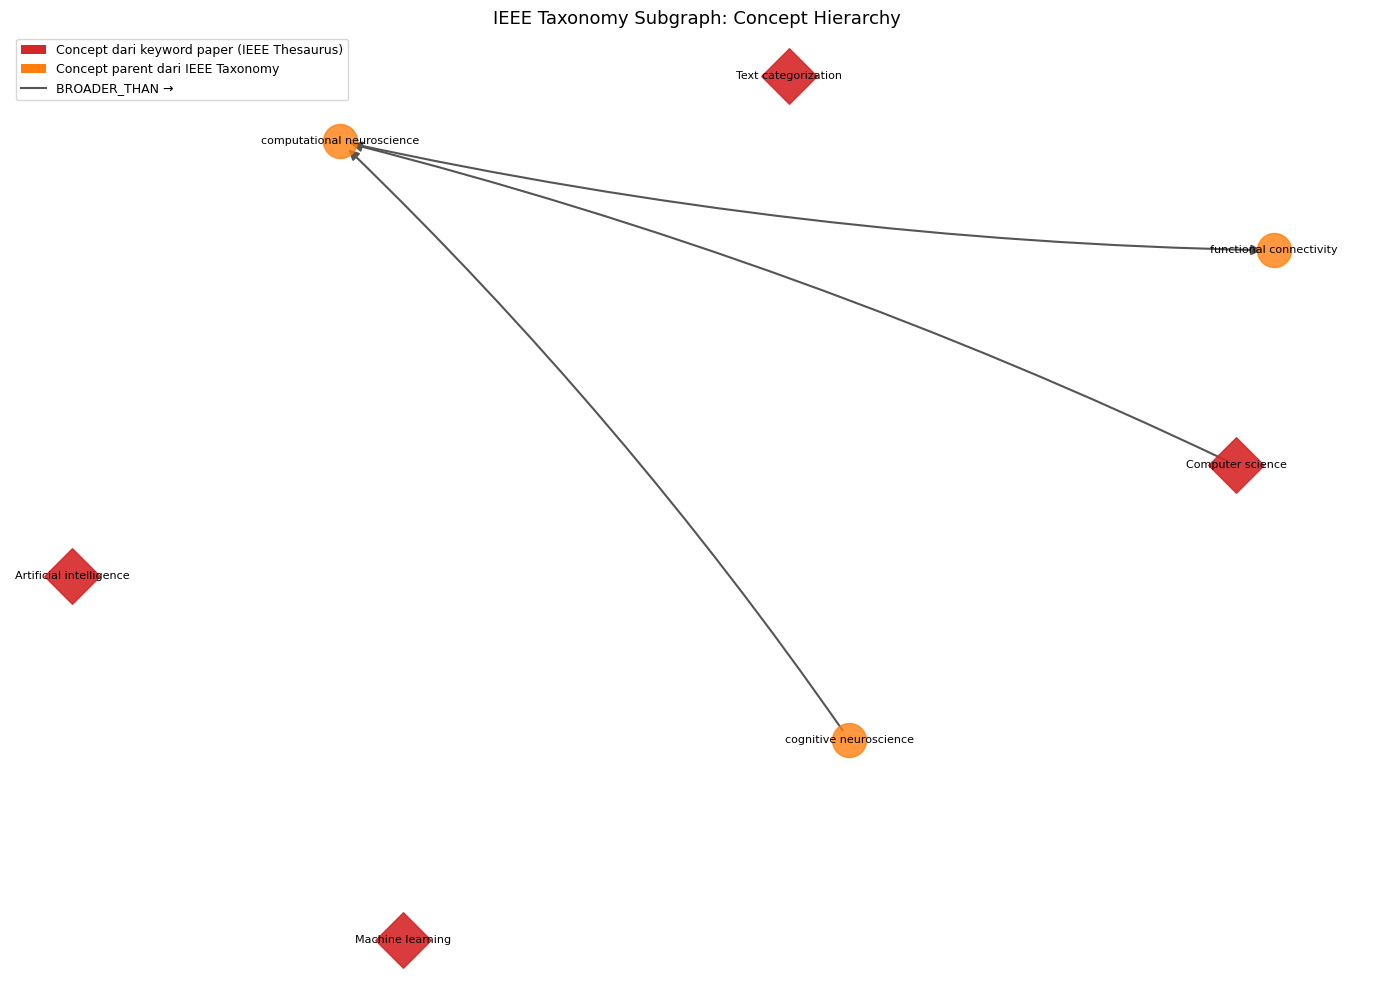

In [53]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

G_tax = nx.DiGraph()

# Label yang dipakai dari keyword paper
keyword_labels = set(df_concepts_used["pref_label"].str.lower().str.strip().tolist())

# Tambah semua nodes
for _, row in df_concepts_all.iterrows():
    lbl = str(row["pref_label"]).lower().strip()
    G_tax.add_node(
        lbl,
        label=str(row["pref_label"]),
        is_keyword=lbl in keyword_labels,
        source=row.get("source", "unknown")
    )

# Tambah edges dari taxonomy filtered
for _, row in df_taxonomy_filtered.iterrows():
    child  = row["child_label"].lower().strip()
    parent = row["parent_label"].lower().strip()
    if child in G_tax and parent in G_tax:
        G_tax.add_edge(child, parent, rel="BROADER_THAN")

print(f"Taxonomy subgraph: {G_tax.number_of_nodes()} nodes, {G_tax.number_of_edges()} edges")

# Pisah node berdasarkan tipe
keyword_nodes = [n for n, d in G_tax.nodes(data=True) if d.get("is_keyword")]
parent_nodes  = [n for n, d in G_tax.nodes(data=True) if not d.get("is_keyword")]

labels_display = {n: d.get("label", n) for n, d in G_tax.nodes(data=True)}

# Layout: coba hierarchical, fallback ke spring
try:
    pos = nx.nx_agraph.graphviz_layout(G_tax, prog="dot")
except Exception:
    pos = nx.spring_layout(G_tax, seed=42, k=2.0)

fig, ax = plt.subplots(figsize=(14, 10))

# Concept dari keyword paper → merah diamond
nx.draw_networkx_nodes(G_tax, pos,
    nodelist=keyword_nodes,
    node_color="#d62728", node_shape="D",
    node_size=800, alpha=0.9, ax=ax)

# Concept parent dari taxonomy → oranye
nx.draw_networkx_nodes(G_tax, pos,
    nodelist=parent_nodes,
    node_color="#ff7f0e", node_size=600,
    alpha=0.8, ax=ax)

nx.draw_networkx_edges(G_tax, pos,
    edge_color="#555555", width=1.5,
    arrows=True, arrowsize=15,
    connectionstyle="arc3,rad=0.05", ax=ax)

nx.draw_networkx_labels(G_tax, pos,
    labels=labels_display,
    font_size=8, ax=ax)

legend = [
    Patch(facecolor="#d62728", label="Concept dari keyword paper (IEEE Thesaurus)"),
    Patch(facecolor="#ff7f0e", label="Concept parent dari IEEE Taxonomy"),
    Line2D([0],[0], color="#555555", lw=1.5, label="BROADER_THAN →"),
]
ax.legend(handles=legend, loc="upper left", fontsize=9)
ax.set_title("IEEE Taxonomy Subgraph: Concept Hierarchy", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()


In [55]:
import networkx as nx

# ── Cek tipe kedua graph sebelum merge ────────────────────────────────────────
print(f"G_kw  type : {'DiGraph' if G_kw.is_directed() else 'Graph'}")
print(f"G_tax type : {'DiGraph' if G_tax.is_directed() else 'Graph'}")

# ── Konversi G_kw ke DiGraph supaya bisa di-compose dengan G_tax ─────────────
# Relasi HAS_KEYWORD dan REFERS_TO memang punya arah, jadi DiGraph lebih tepat
G_kw_directed = G_kw.to_directed()

print(f"\nSetelah konversi:")
print(f"G_kw_directed type : {'DiGraph' if G_kw_directed.is_directed() else 'Graph'}")
print(f"G_tax         type : {'DiGraph' if G_tax.is_directed() else 'Graph'}")

# ── Merge kedua graph ─────────────────────────────────────────────────────────
G_full = nx.compose(G_kw_directed, G_tax)

print()
print("=" * 45)
print(f"  Full KG Preview")
print(f"  Nodes : {G_full.number_of_nodes()}")
print(f"  Edges : {G_full.number_of_edges()}")
print("=" * 45)

# Top 10 nodes by degree centrality
centrality = nx.degree_centrality(G_full)
top10 = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 node by degree centrality:")
for node_id, score in top10:
    node_data = G_full.nodes.get(node_id, {})
    lbl   = node_data.get("label", str(node_id)[:40])
    ntype = node_data.get("type", "Concept")
    print(f"  [{ntype:15s}] {lbl:40s} → {score:.4f}")


G_kw  type : Graph
G_tax type : DiGraph

Setelah konversi:
G_kw_directed type : DiGraph
G_tax         type : DiGraph

  Full KG Preview
  Nodes : 48
  Edges : 75

Top 10 node by degree centrality:
  [Paper          ] Rule-Based Adaptive Chatbot on WhatsApp for V... → 0.5957
  [Paper          ] Klasifikasi Level Retinopati Diabetik Menggun... → 0.2553
  [Paper          ] Analisis Kinerja Retrieval Augmented Generati... → 0.2128
  [Paper          ] Pengembangan Sistem Informasi Persediaan Guda... → 0.1702
  [Paper          ] Optimization and Evaluation of IndoBERT, BiLS... → 0.1277
  [KeywordMention ] text classification                      → 0.0851
  [KeywordMention ] computer science                         → 0.0851
  [KeywordMention ] machine learning                         → 0.0851
  [KeywordMention ] artificial intelligence                  → 0.0851
  [Concept        ] computational neuroscience               → 0.0638


In [56]:
# Hitung node per type
from collections import Counter

type_counts = Counter(
    d.get("type", "Concept")
    for _, d in G_full.nodes(data=True)
)

print("Node distribution:")
for ntype, count in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {ntype:20s} : {count}")

print()

# Connected components
undirected = G_full.to_undirected()
components = list(nx.connected_components(undirected))
print(f"Connected components : {len(components)}")
print(f"Largest component    : {max(len(c) for c in components)} nodes")
print(f"Isolated nodes       : {sum(1 for c in components if len(c) == 1)}")

print()

# Edge distribution
edge_types = Counter(
    d.get("rel", "unknown")
    for _, _, d in G_full.edges(data=True)
)
print("Edge distribution:")
for etype, count in sorted(edge_types.items(), key=lambda x: -x[1]):
    print(f"  {etype:25s} : {count}")


Node distribution:
  KeywordMention       : 32
  Concept              : 11
  Paper                : 5

Connected components : 9
Largest component    : 18 nodes
Isolated nodes       : 3

Edge distribution:
  HAS_KEYWORD               : 64
  REFERS_TO                 : 8
  BROADER_THAN              : 3


In [59]:
import pandas as pd
from itertools import combinations

# ── Rebuild df_collab dari df_paper_authors ───────────────────────────────────
collab_edges = []
for paper_id, group in df_paper_authors.groupby("paper_id"):
    authors_in_paper = group["scholar_id"].dropna().unique().tolist()
    for a, b in combinations(authors_in_paper, 2):
        collab_edges.append({
            "scholar_id_a": a,
            "scholar_id_b": b,
            "paper_id": paper_id
        })

df_collab = pd.DataFrame(collab_edges)
print(f"Collab edges total: {len(df_collab)}")

# ── Enrich dengan nip dari df_lecturers ──────────────────────────────────────
collab_enriched = df_collab.merge(
    df_lecturers[["nip", "scholar_id"]].rename(
        columns={"nip": "nip_a", "scholar_id": "scholar_id_a"}),
    on="scholar_id_a", how="left"
).merge(
    df_lecturers[["nip", "scholar_id"]].rename(
        columns={"nip": "nip_b", "scholar_id": "scholar_id_b"}),
    on="scholar_id_b", how="left"
)

# Kolaborasi internal: keduanya dosen internal (punya nip)
collab_internal = collab_enriched[
    collab_enriched["nip_a"].notna() & collab_enriched["nip_b"].notna()
].copy()

# Kolaborasi eksternal: salah satu bukan dosen internal
collab_external = collab_enriched[
    collab_enriched["nip_a"].isna() | collab_enriched["nip_b"].isna()
].copy()

print(f"Collab internal (dosen–dosen)  : {len(collab_internal)}")
print(f"Collab external (ada non-dosen): {len(collab_external)}")


Collab edges total: 7
Collab internal (dosen–dosen)  : 0
Collab external (ada non-dosen): 7


In [60]:
# Match df_paper_authors ke df_lecturers via scholar_id
matched = df_paper_authors.merge(
    df_lecturers[["nip", "nama_norm", "scholar_id", "prodi", "nidn"]],
    on="scholar_id",
    how="inner"
)

unmatched = df_paper_authors[
    ~df_paper_authors["scholar_id"].isin(df_lecturers["scholar_id"])
]

print(f"Matched (author → dosen internal) : {len(matched)}")
print(f"Unmatched (author eksternal)       : {len(unmatched)}")

if len(matched) == 0:
    print("\n⚠️  Match = 0. Cek scholar_id di kedua tabel:")
    print("  scholar_id dari paper (sample):")
    print(" ", df_paper_authors["scholar_id"].dropna().unique()[:5].tolist())
    print("  scholar_id dari lecturers (sample):")
    print(" ", df_lecturers["scholar_id"].dropna().unique()[:5].tolist())


Matched (author → dosen internal) : 0
Unmatched (author eksternal)       : 9

⚠️  Match = 0. Cek scholar_id di kedua tabel:
  scholar_id dari paper (sample):
  ['hn5jrnAAAAAJ', 'CxdwNaYAAAAJ', 'cPj-iOIAAAAJ', 'RvG7jG4AAAAJ', 'N6RJilIAAAAJ']
  scholar_id dari lecturers (sample):
  []


In [33]:
# Concept yang sudah terpakai dari paper kamu
used_uris = set(df_concepts_used["concept_uri"].dropna().tolist())
print(f"Concept terpakai: {len(used_uris)}")

# Level 1: edges yang langsung melibatkan concept terpakai
direct_edges = df_taxonomy_edges_full[
    df_taxonomy_edges_full["child_uri"].isin(used_uris) |
    df_taxonomy_edges_full["parent_uri"].isin(used_uris)
]

# Level 2: tambah satu hop lagi (parent dari parent)
parent_uris = set(direct_edges["parent_uri"].tolist())
second_hop = df_taxonomy_edges_full[
    df_taxonomy_edges_full["child_uri"].isin(parent_uris) |
    df_taxonomy_edges_full["parent_uri"].isin(parent_uris)
]

df_taxonomy_filtered = pd.concat([direct_edges, second_hop]).drop_duplicates()
print(f"Taxonomy edges relevan (2-hop): {len(df_taxonomy_filtered)}")
df_taxonomy_filtered.head(10)


Concept terpakai: 4


KeyError: 'child_uri'

In [61]:

# [FIX CELL 34] Diagnosa kolom df_taxonomy_edges_full
print("Kolom df_taxonomy_edges_full:", df_taxonomy_edges_full.columns.tolist())
print("Shape:", df_taxonomy_edges_full.shape)
df_taxonomy_edges_full.head(3)

Kolom df_taxonomy_edges_full: ['child_label', 'parent_label', 'rel', 'source_uri']
Shape: (3385, 4)


,child_label,parent_label,rel,source_uri
0,3g mobile communication,4g mobile communication,BROADER_THAN,https://ieee-taxonomy.org/3g_mobile_communicat...
1,6g mobile communication,ambient networks,BROADER_THAN,https://ieee-taxonomy.org/6g_mobile_communicat...
2,dielectrics,dielectric constant,BROADER_THAN,https://ieee-taxonomy.org/_....dielectrics_......


In [62]:
# [CELL 35] Cek kolom df_concepts_used
print("Kolom df_concepts_used:", df_concepts_used.columns.tolist())
print(df_concepts_used.head(3))

Kolom df_concepts_used: ['concept_uri', 'pref_label', 'alt_labels', 'source', 'pref_label_norm', 'alt_labels_norm']
                                         concept_uri           pref_label  \
0  https://ieee-thesaurus.org/schema#text_categor...  Text categorization   
1  https://ieee-thesaurus.org/schema#computer_eng...     Computer science   
2  https://ieee-thesaurus.org/schema#machine_lear...     Machine learning   

              alt_labels          source      pref_label_norm  \
0  [Text classification]  ieee-thesaurus  text categorization   
1                     []  ieee-thesaurus     computer science   
2                     []  ieee-thesaurus     machine learning   

         alt_labels_norm  
0  [text classification]  
1                     []  
2                     []  


In [ ]:
from neo4j import GraphDatabase

NEO4J_URI  = os.environ.get("NEO4J_URI")
NEO4J_USER = os.environ.get("NEO4J_USER", "neo4j")
NEO4J_PASS = os.environ.get("NEO4J_PASS")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

def create_lecturer_node(tx, row):
    tx.run("""
        MERGE (d:Dosen {nip: $nip})
        SET d.nama = $nama,
            d.nidn = $nidn,
            d.prodi = $prodi,
            d.scholar_id = $scholar_id,
            d.scopus_id = $scopus_id,
            d.sinta_id = $sinta_id
    """, **row)

with driver.session() as session:
    for _, row in df_lecturers.iterrows():
        session.execute_write(create_lecturer_node, row.to_dict())

print(f"✅ {len(df_lecturers)} Dosen nodes created/merged")

In [63]:

# [CELL 36] FIX: Rebuild matched dosen internal via scopus_id (bukan scholar_id)
# scholar_id kosong di tabel lecturers, gunakan scopus_id sebagai identifier

# Cek kolom df_paper_authors
print("Kolom df_paper_authors:", df_paper_authors.columns.tolist())
print("Sample author_ids:", df_paper_authors["author_id"].dropna().unique()[:5].tolist())
print("Sample scopus_id dari lecturers:", df_lecturers["scopus_id"].dropna().unique()[:5].tolist())

Kolom df_paper_authors: ['paper_id', 'author_name', 'scholar_id', 'year', 'title']


KeyError: 'author_id'